# 1.中间件概述

在 create_agent() 的底层运行机制中，有几个重要的组件，分别是：
- 模型(Model) ：Agent 的“大脑”，负责理解任务与决策推理。
- 工具(Tools) ：Agent 的“手脚”，执行模型自己做不到的外部操作。
- 系统提示词(System Prompt) ：Agent的“角色”，告诉模型该怎么想、参考什么上下文。
- 中间件(Middleware) ：Agent的“中枢”，在执行流程的关键节点进行拦截、控制和增强。  

声明如下：

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware,HumanInTheLoopMiddleware

agent = create_agent(
    model="gpt-5.4-mini",
    tools=[...],
    middleware=[
        SummarizationMiddleware(...),
        HumanInTheLoopMiddleware(...)
    ],
)

## 1.1 什么是中间件
Middleware(中间件)，简单说就是Agent 执行过程中的钩子函数，是 LangChain 1.x 的“王牌”工程化能力。  
- 钩子是框架或系统在某些关键执行点暴露的扩展接口。开发者可以“挂上”自己的逻辑，在那些点上插入、修改或替换行为，而无需改变主流程代码。就像在流水线上某个环节设置了一个“检查点”或“插入器”。  

借助中间件，开发者可以高度定制和控制Agent运行的每一个环节，是处理 Agent 生命周期的标准方式。  

### 情况1：没有中间件的Agent架构：  

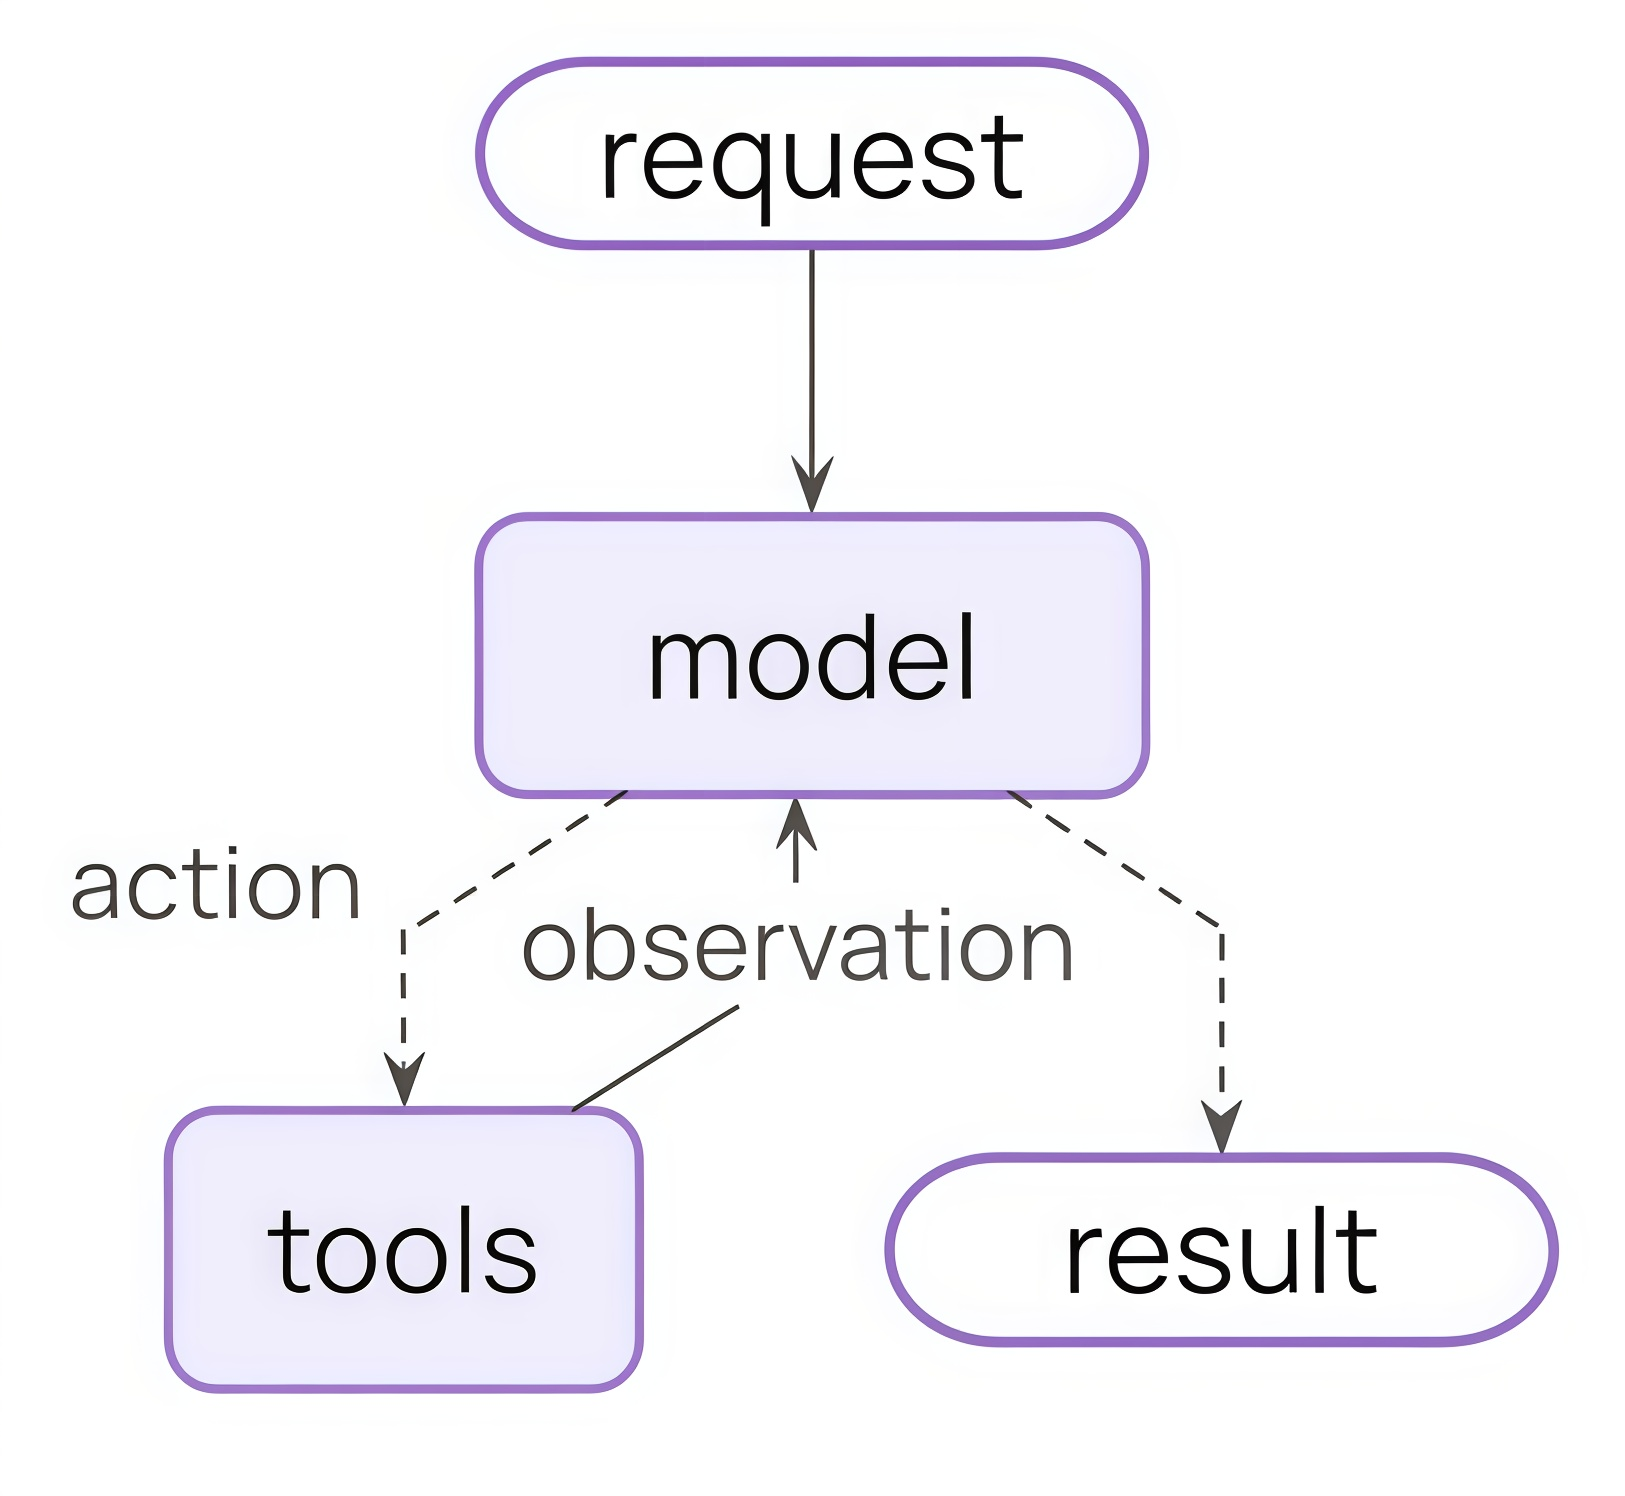

### 情况2：添加中间件之后的Agent架构变为：  

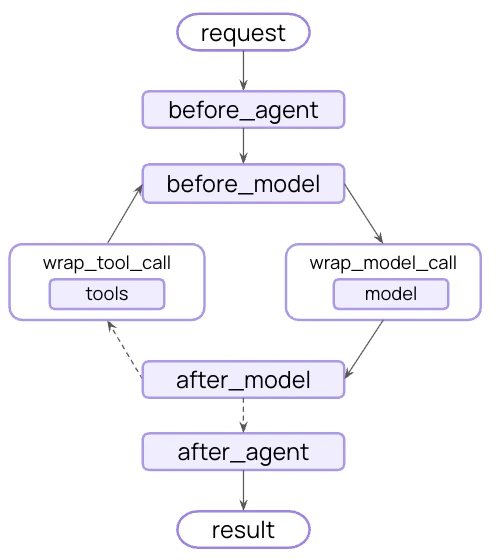

在 LangChain 的 Agent 执行循环中，比如 “模型调用前”、“模型调用后”、“工具调用前后” 设置一些钩子（hooks），让你在不改 Agent 主体逻辑的情况下实现策略与治理。

## 1.2 为什么需要中间件
如果没有中间件，Agent 的执行流程通常比较直接：  
**用户输入 → 拼接提示词/消息 → 调用模型 → 如有需要调用工具 → 返回结果**

这种方式对于简单场景已经足够，但一旦进入真实项目，往往会遇到很多额外需求，例如：
- 想根据问题复杂度动态切换模型；
- 想限制某些用户只能调用部分工具；
- 想在工具报错时自动重试或返回兜底结果；
- 想在模型调用前插入额外的系统提示；
- 想记录每一步的执行日志，方便排查问题；
- 想在敏感信息出现时阻断执行；
- 想在正式执行工具前增加人工审批。

这些需求有一个共同特点：它们不是 Agent 的核心业务逻辑，但又会影响 Agent 的执行过程。如果把这些逻辑全部直接写进主流程，会带来几个问题：

**1）主流程会迅速变乱**  
Agent 本身只需要关心“理解用户需求、决定是否调用工具、生成结果”，
但一旦把日志、鉴权、重试、风控、审计都塞进去，主逻辑就会变得臃肿。

**2）很多逻辑是横切需求，难以复用**  
例如日志、重试、风控、权限控制，通常不是某一个 Agent 独有的，而是多个 Agent 都需要。如果直接
写死在每个 Agent 里，会产生大量重复代码。

**3）流程控制粒度不够细**  
有些逻辑必须发生在“模型调用前”，有些要发生在“工具调用后”，如果没有统一的执行拦截点，开发者只
能手动改主流程，既麻烦又容易出错。

**4）后期维护成本高**  
当你需要增加一个新规则，例如“所有外部工具调用前都先做审计”，如果系统没有中间件机制，往往需
要修改很多处代码。

总结：  
中间件的价值就在于把这些与业务无关、但与执行过程强相关的横切逻辑，从 Agent 主流程中分离出来。让Agent 主体代码聚焦业务，而借助中间件，实现“ 拦截流程、修改流程、增强流程”。

简言之，LangChain 1.x 的中间件能实现如下功能：  
✅ 日志与分析 - 追踪行为、调试、性能监控  
✅ 转换 - 修改提示词、工具选择、输出格式  
✅ 容错 - 重试、降级、早期终止  
✅ 安* - 限流、守护规则、PII 检测  

## 1.3 中间件的分类
根据LangChain是否已经定义了来分类：
- **自定义中间件**：允许开发者自定义，从而实现更加灵活的Agent行为管理
- **内置中间件**：LangChain实现并提供的
    - 模型供应商定制的中间件：依赖于特定模型服务的实现（不是本课的重点）
    - 和模型供应商无关的中间件。LangChain提供的与供应商无关的中间件如下：  
链接：https://docs.langchain.com/oss/python/langchain/middleware/overview

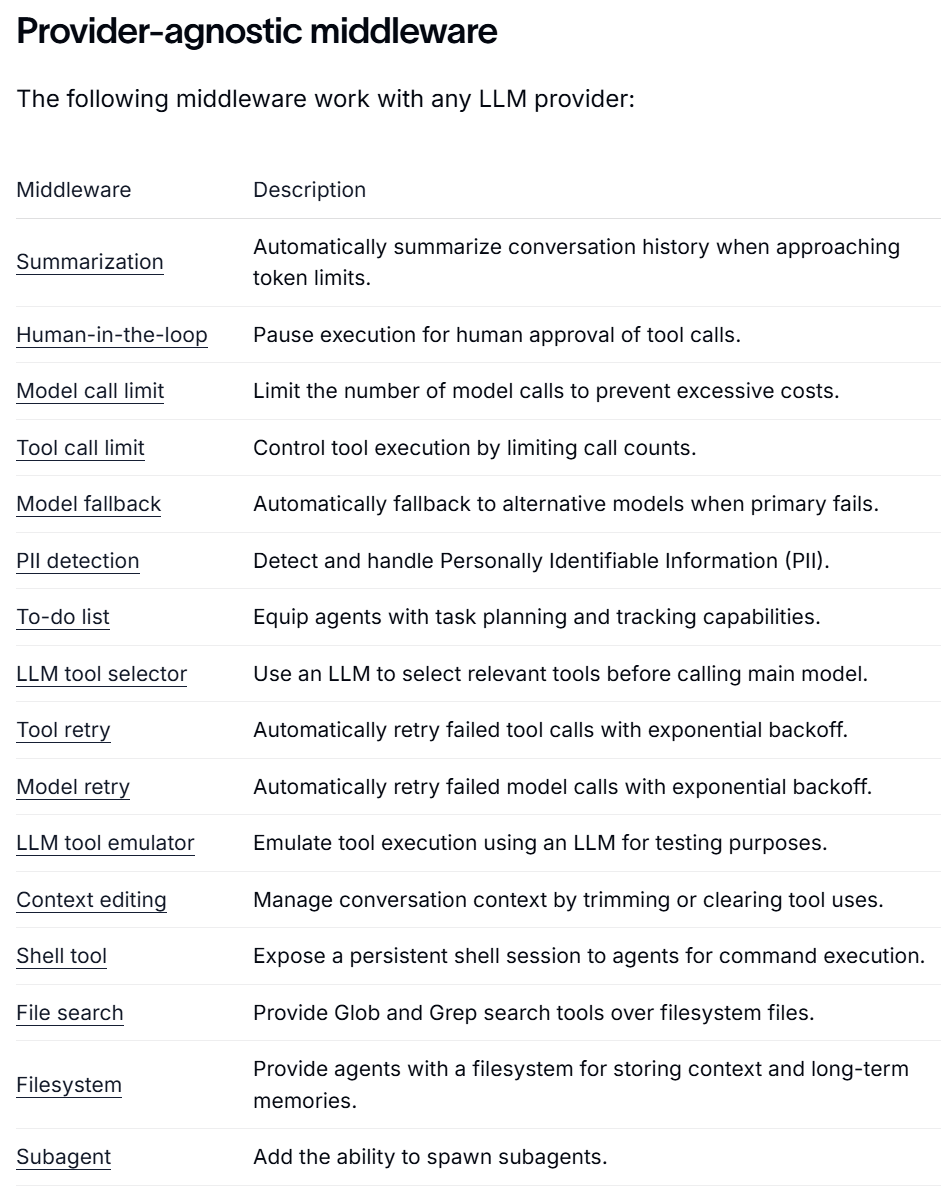

## 1.4 和模型供应商无关的内置中间件分类
LangChain提供的和模型供应商无关的内置中间件分为六个类别  
### 类型1：成本与资源控制类
核心目标：控成本、控配额、避免无限调用  
这类中间件主要解决“ Agent太贵、太能跑、停不下来”的问题。  
包含：
- **Model call limit**：限制模型调用次数，防止一次任务反复请求 LLM，导致费用失控
- **Tool call limit**：限制工具调用次数，避免 Agent 无限试错、死循环调工具
- **Summarization**：在上下文快满时自动总结历史，减少 token 消耗
- **Context editing**：裁剪上下文、清理工具调用痕迹，本质上也是为了节省上下文成本

业务场景理解：  
适合生产环境的成本治理、配额治理、长会话优化、SaaS 产品控费。

### 类型2：稳定性与容错保障类
核心目标：保证服务不中断、失败后尽量自动恢复  
这类中间件主要解决“ 调用失败怎么办、模型挂了怎么办、工具超时怎么办”。  
包含：  
- **Model fallback**：主模型失败时切换备用模型
- **Model retry**：模型调用失败后自动重试
- **Tool retry**：工具调用失败后自动重试


业务场景理解：  
适合线上生产系统，尤其是多模型、多工具依赖的 Agent。  
本质上是在做 高可用、容灾、鲁棒性建设。

### 类型3：安全与合规风控类
核心目标：让 Agent 可控、可审、合规  
这类中间件主要解决“ Agent乱执行、泄露敏感信息、做危险操作”的问题。  
包含：
- **Human-in-the-loop**：在关键工具调用前暂停，等人工审批
- **PII detection**：检测和处理个人敏感信息
- **Model call limit / Tool call limit**：某种意义上也可归到风控，因为它能防止异常滥用


业务场景理解：  
适合企业内部系统、客服系统、审批流、数据查询类 Agent。  
尤其是涉及：发邮件、调数据库、调财务/人事系统、导出敏感信息、执行外部动作等

### 类型4：决策增强与智能编排类
核心目标：提升 Agent 的决策质量和任务拆解能力  
这类中间件主要解决“ Agent不够聪明、不会规划、不会先筛工具”的问题。  
包含：  
- **To-do list**：给 Agent 增加任务规划、分步骤执行和状态跟踪能力
- **LLM tool selector**：当工具太多时，用子模型筛选最相关的几个工具交给主模型
- **Subagent**：允许生成子Agent，把复杂任务拆给不同角色处理


业务场景理解：  
适合复杂任务流，比如：研究型 Agent、多步骤分析、报告生成、多角色协作、长链路任务编排等。  
这类本质上是在增强 Agent的“脑子”与“组织能力”。

### 类型5：执行能力扩展类
核心目标：给 Agent 更多“手脚”  
这类中间件主要解决“ Agent只能聊天，不能真正操作环境”的问题。  
包含：  
- **Shell tool**：给 Agent 持久 shell，会执行命令
- **File search**：给 Agent 文件搜索能力，能做 Glob/Grep
- **Filesystem**：给 Agent 文件系统读写与长期存储能力


业务场景理解：  
适合工程 Agent、代码 Agent、本地自动化 Agent、运维 Agent。  
本质上是把 Agent 从“纯推理”扩展成“能操作环境的执行体”。

### 类型6：开发调试与测试辅助类
核心目标：方便开发、测试、验证 Agent 行为  
这类中间件主要不是直接服务业务，而是服务于研发和调试阶段。  
包含：  
- **LLM tool emulator**：用 LLM 模拟工具执行，便于测试（最典型）
- **Summarization**：有时也可辅助调试长会话表现
- **Context editing**：可用于测试上下文裁剪效果
- **Human-in-the-loop**：也常用于调试高风险步骤


业务场景理解：  
适合开发阶段快速验证流程、做 mock、减少真实工具依赖。

# 2、常用内置中间件的使用
LangChain 1.0 提供了 16 个预置中间件，开箱即用。  
我们不会逐个介绍上述与模型供应商无关的所有内置中间件，这里将与模型供应商无关的内置中间件分成两部分：   
常用内置中间件（本节）， 其它内置中间件（下节）。  
第一部分将会详细讲解，第二部分提供测试代码和结果，快速演示。  

## 2.1 SummarizationMiddleware中间件
**作用**：对历史消息列表进行摘要&总结，达到压缩上下文的效果。  
**原理**：在达到触发条件时，调用大模型对历史消息进行摘要， 将摘要的结果作为HumanMessage ，放到消息列表最开始的位置。

### 2.1.1 参数说明
注意：本节中间件的参数说明不保证包含完整参数列表，不常用或被标记为过时的参数被省略。
#### 参数1：model —用于摘要的模型
可以是模型名称也可以是模型对象，如果传递的是模型名称，底层会调用init_chat_model 初始化模型。
#### 参数2：trigger —摘要触发条件
是一个列表，每个元素对应一个条件，当任一条件满足时，触发摘要。
1. tokens ：token的数量，历史token的累计数量达到该值触发摘要。
2. messages ：历史消息数量，历史消息条数达到该值触发摘要。
3. fraction ：上下文长度比例。历史token的累计数量达到模型的max_input_tokens*fraction 触发摘要

如果条件包含fraction ，要求模型的profile包含max_input_tokens ，Deepseek模型的profile为空，此时需要手动添加该配置项。Deepseek-V3.2的上下文长度为128K。

#### 参数3：keep —摘要时保留的原始消息
支持三种条件，但和trigger不同，keep同一时间只接收一种条件。  
1. tokens ：摘要时保留的token数量。
2. messages ：摘要时保留的历史消息条数。
3. fraction ：摘要时保留max_input_tokens*fraction 个token。

#### 参数4：token_counter —统计token数量的函数
默认使用LangChain提供的count_tokens_approximately ，一般不用更改。  
    对于纯文本消息，该函数的大致思路是先统计消息的字符数，也就是len(字符串) ，然后再除以每个token大致的字符数，转换为粗略的token数，再加一些额外开销。作为估算的token数。
#### 参数5：summary_prompt —摘要时的自定义提示词
该提示词需要包含{messages} 占位符，使得历史消息列表可以被插入。不指定则使用内置提示词。
#### 参数6：trim_token_to_summarize —摘要时历史消息的最大token数
如果历史消息token数大于该值，则会被裁剪。默认为" 4000 "。  
如果trigger用token作为度量，调大触发阈值时，当前配置项应相应调整，否则会丢失信息。

### 2.1.2 举例1 测试trigger、keep参数

In [1]:
from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv

load_dotenv()
custom_profile = {
    "max_input_tokens": 128_000
}

model = init_chat_model(
    model="qwen3.6-flash",
    model_provider="openai",
    profile=custom_profile,
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL")
)

注意上面的model是给middleware使用的  
**profile需要显式指定，用于max_input_tokens*fraction计算**  
后续代码：

In [2]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain.messages import SystemMessage, HumanMessage, AIMessage

messages = [
    SystemMessage("你是个非常友好的AI助手"),
    HumanMessage("你好啊，我是老王，你是谁？"),
    AIMessage("你好老王，我是小王"),
    HumanMessage("好的小王，很高兴认识你"),
    AIMessage("你高兴得太早了"),
    HumanMessage("呵呵，你什么意思")
]

agent = create_agent(
    model="deepseek-v4-flash",
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=[
                ("tokens", 100),
                ("messages", 6),
                ("fraction", 0.001)
            ],
            keep=("messages", 2)
        )
    ]
)

response = agent.invoke({
    "messages": messages
})

for msg in response["messages"]:
    msg.pretty_print()

c:\Users\huan.zheng\AppData\Local\miniconda3\envs\langchain1\Lib\site-packages\langgraph\checkpoint\base\__init__.py:17: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


================================ Human Message =================================

Here is a summary of the conversation to date:

## SESSION INTENT
建立初步联系与问候，等待用户提出具体任务、问题或需求。

## SUMMARY
完成了基础的身份介绍与寒暄。系统设定AI为“非常友好的AI助手”，用户自报姓名为“老王”，AI回应自称“小王”。双方已交换称呼并表达友好态度。当前对话仅处于开场阶段，无实质业务目标、技术决策、策略选择或 rejected options。

## ARTIFACTS
None

## NEXT STEPS
等待用户输入具体指令、问题、创作需求或任务描述，以便开展针对性工作。
================================== Ai Message ==================================

你高兴得太早了
================================ Human Message =================================

呵呵，你什么意思
================================== Ai Message ==================================

哈哈，老王别误会！我那句“你高兴得太早了”是跟你开玩笑的，意思是咱们这才刚认识，还没开始正经干活呢，你先别急着乐呵。我可没有什么坏心眼！

来，现在你想聊点啥，或者有什么需要我帮忙的，尽管说，小王一定尽力配合！😄


分析：
1. 我们通过自定义profile指定了max_input_tokens，才能用fraction作为度量，否则报错。
2. 三个条件触发条件至少有一个满足，触发了摘要。
3. 摘要结果作为HumanMessage，传入消息列表头部
4. keep要求保留两条消息，则最新两条消息原样保留。

### 2.1.3 举例2 测试summary_prompt参数

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain.messages import SystemMessage, HumanMessage, AIMessage
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)

custom_profile = {
    "max_input_tokens": 1_000_000
}

model = init_chat_model(
    model="qwen3.6-flash",
    model_provider="openai",
    profile=custom_profile,
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL")
)

messages = [
    SystemMessage("你是个非常有好的AI助手"),
    HumanMessage("你好啊，我是老王，你是谁？"),
    AIMessage("你好老王，我是小王"),
    HumanMessage("好的小王，很高兴认识你"),
    AIMessage("你高兴得太早了"),
    HumanMessage("呵呵，你什么意思，你是谁？")
]

agent = create_agent(
    model="deepseek-v4-flash",
    middleware=[
        SummarizationMiddleware(
            model=model,
            trigger=[
                ("tokens", 100),
                ("messages", 6),
                ("fraction", 0.0001)
            ],
            keep=("messages", 2),
            summary_prompt="对历史消息摘要，消息列表如下\n{messages}"  # 必须要{messages}占位符用于存放摘要
        )
    ]
)

response = agent.invoke({
    "messages": messages
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Here is a summary of the conversation to date:

**历史消息摘要：**
当前为对话初始寒暄阶段。用户表明身份为“老王”，AI以“小王”回应，双方已完成友好问候与初步认识。系统已设定AI为优质助手角色，整体交互氛围轻松熟络，后续沟通将基于此身份设定继续展开。
================================== Ai Message ==================================

你高兴得太早了
================================ Human Message =================================

呵呵，你什么意思，你是谁？
================================== Ai Message ==================================

哈哈，老王您这话问的，我哪儿敢有什么“意思”啊。我是小王，就是您身边那个随叫随到的助手。刚才说“高兴”是真高兴——终于跟您接上头了，总得先乐呵一下不是？不过您说得对，光高兴可不行，还得看实际行动。您尽管吩咐，我等着您考察呢。


分析
1. 摘要结果和案例一明显不同，提示词生效了
2. 摘要包含了历史对话记录， {messages} 被替换为历史消息列表。

## 2.2 HumanInTheLoopMiddleware中间件
HumanInTheLoopMiddleware（人在环中间件、人工审核中间件）在工具调用前中断Agent运行，等待用户对工具调用请求决策。  
可选的决策有： 
- approve（同意执行） 
- edit（编辑调用配置后执行） 
- reject（拒绝执行）

### 2.2.1 参数说明
#### 参数1：interrupt_on —工具名和中断策略的映射
策略可以是True、False或InterruptOnConfig对象，精细控制决策选项。  
比如：

In [ ]:
interrupt_on={
    "get_weather": True,
    "read_email_tool": False,
    "send_email_tool": {
        "allowed_decisions": ["approve", "reject"],
    },
}

1. True表示所有决策(approve, edit, reject) 都可以选择，相当于

In [ ]:
"get_weather": {
    "allowed_decisions": ["approve", "edit", "reject"],
}

2. False表示不中断，即无需审批即可执行。
3. InterruptOnConfig 是一个TypedDict的子类，可以用字典直接赋值。支持的Key有：  
    ① allowed_decisions 精细控制中断后允许的决策。  
    ② description ：特定工具的中断描述信息，优先级高于description_prefix，后者会更改所有工具中断的描述。

#### 参数2：description_prefix —自定义中断描述
默认为"Tool execution requires approval" ，下面的举例可以看到效果。

### 2.2.2 举例过程1：调用前中断
**注意：本例需要从中断的位置让Agent继续运行，这就需要用到短期记忆，这里先使用即可。**   
创建Agent时通过checkpointer参数启用了短期记忆，在调用时通过传递相同的config加载记忆。记住固定用法即可。

In [5]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
# 从.env文件中加载环境变量
load_dotenv(override=True)

model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    profile=custom_profile,
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL")
)

In [6]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import HumanMessage
from langchain.tools import tool
from langgraph.types import Command
from rich import print as rprint
@tool
def get_weather(city: str, is_forcast: bool = False) -> str:
    """
    查询指定城市天气

    Args:
        city: 城市名称
        is_forcast: 是否包含明日天气预报？
    """
    res = f"{city}今天天气不错"
    if is_forcast:
        res += "\n明天下雨"
    return res

@tool
def get_news() -> str:
    """
    查询当日新闻
    """
    return "中方三艘油轮通过霍尔木兹海峡"

@tool
def read_email_tool(email_id: str) -> str:
    """通过邮件ID读取内容的伪函数"""
    return f"邮件ID：{email_id}\n是空的"

@tool
def send_email_tool(recipient: str, subject: str, body: str) -> str:
    """发送邮件伪函数"""
    print(">>> 真的执行发送邮件工具了")
    return f"发送给 {recipient} 的邮件标题是：{subject}，内容：{body}"

agent = create_agent(
    model=model,
    tools=[get_weather, get_news, read_email_tool, send_email_tool],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
        interrupt_on={
            "get_weather": True,
            "get_news": True,
            "read_email_tool": False,
            "send_email_tool": {
                "allowed_decisions": ["approve", "reject"],
                "description": "发送邮件中断啦"
            },
        },
        description_prefix="中断啦"
        ),
    ],
)

config = {"configurable": {"thread_id": "1"}}

# 第一次调用：会暂停在发送邮件前
response = agent.invoke(
    {
        "messages": [
            HumanMessage(content="请帮我查询今天北京的天气"
                "查询今日新闻"
                "查看ID为 'sk2131421' 的邮件内容，"
                "向18701768310@163.com发送邮件，标题是'哈哈哈'，内容是：'你好啊'"
                "同时做这四件事"
            )
        ]
    },
    config=config,
)

print("==== 第一次 invoke 返回 ====")
print("========= 原始响应 =========")
rprint(response)
print("========= 美化输出 =========")
for msg in response["messages"]:
    msg.pretty_print()

# 关键：看中断信息
interrupts = response.get("__interrupt__", [])
print("========== interrupts ==========")
rprint(interrupts)
# print("==== 逐个打印 interrupt 请求 ====")
action_requests = interrupts[0].value["action_requests"]
for action_request in action_requests:
    rprint(action_request)

==== 第一次 invoke 返回 ====
========= 原始响应 =========


{
    'messages': [
        HumanMessage(
            content="请帮我查询今天北京的天气查询今日新闻查看ID为 'sk2131421' 
的邮件内容，向18701768310@163.com发送邮件，标题是'哈哈哈'，内容是：'你好啊'同时做这四件事",
            additional_kwargs={},
            response_metadata={},
            id='203c5f11-be73-499d-b327-66c678d5f5c6'
        ),
        AIMessage(
            content='我来同时为您处理这四件事：查询北京天气、查看今日新闻、读取邮件、发送邮件。',
            additional_kwargs={
                'refusal': None,
                'reasoning_content': "The user wants me to do four things simultaneously:\n1. Query today's weather
in Beijing\n2. Query today's news\n3. Read email with ID 'sk2131421'\n4. Send email to 18701768310@163.com with 
subject '哈哈哈' and body '你好啊'\n\nThese are all independent, so I can call them in parallel."
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 264,
                    'prompt_tokens': 595,
                    'total_tokens': 859,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 75,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 512},
                    'prompt_cache_hit_tokens': 512,
                    'prompt_cache_miss_tokens': 83
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e',
                'id': '3a39336a-7317-4173-98e4-385c29d4c80c',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a000d4-a08d-7030-b590-11bf836468a2-0',
            tool_calls=[
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'id': 'call_00_lAW1qbP3GVIOFW9bl0tC9666',
                    'type': 'tool_call'
                },
                {'name': 'get_news', 'args': {}, 'id': 'call_01_khl2Z2BZEg3tC8hJjByB8247', 'type': 'tool_call'},
                {
                    'name': 'read_email_tool',
                    'args': {'email_id': 'sk2131421'},
                    'id': 'call_02_UVvItlHjaZfEwSwV75vs6500',
                    'type': 'tool_call'
                },
                {
                    'name': 'send_email_tool',
                    'args': {'recipient': '18701768310@163.com', 'subject': '哈哈哈', 'body': '你好啊'},
                    'id': 'call_03_MAOAGooOQllkjXXgywtN5908',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 595,
                'output_tokens': 264,
                'total_tokens': 859,
                'input_token_details': {'cache_read': 512},
                'output_token_details': {'reasoning': 75}
            }
        )
    ],
    '__interrupt__': [
        Interrupt(
            value={
                'action_requests': [
                    {
                        'name': 'get_weather',
                        'args': {'city': '北京'},
                        'description': "中断啦\n\nTool: get_weather\nArgs: {'city': '北京'}"
                    },
                    {'name': 'get_news', 'args': {}, 'description': '中断啦\n\nTool: get_news\nArgs: {}'},
                    {
                        'name': 'send_email_tool',
                        'args': {'recipient': '18701768310@163.com', 'subject': '哈哈哈', 'body': '你好啊'},
                        'description': '发送邮件中断啦'
                    }
                ],
                'review_configs': [
                    {'action_name': 'get_weather', 'allowed_decisions': ['approve', 'edit', 'reject']},
                    {'action_name': 'get_news', 'allowed_decisions': ['app

========= 美化输出 =========
================================ Human Message =================================

请帮我查询今天北京的天气查询今日新闻查看ID为 'sk2131421' 的邮件内容，向18701768310@163.com发送邮件，标题是'哈哈哈'，内容是：'你好啊'同时做这四件事
================================== Ai Message ==================================

我来同时为您处理这四件事：查询北京天气、查看今日新闻、读取邮件、发送邮件。
Tool Calls:
  get_weather (call_00_lAW1qbP3GVIOFW9bl0tC9666)
 Call ID: call_00_lAW1qbP3GVIOFW9bl0tC9666
  Args:
    city: 北京
  get_news (call_01_khl2Z2BZEg3tC8hJjByB8247)
 Call ID: call_01_khl2Z2BZEg3tC8hJjByB8247
  Args:
  read_email_tool (call_02_UVvItlHjaZfEwSwV75vs6500)
 Call ID: call_02_UVvItlHjaZfEwSwV75vs6500
  Args:
    email_id: sk2131421
  send_email_tool (call_03_MAOAGooOQllkjXXgywtN5908)
 Call ID: call_03_MAOAGooOQllkjXXgywtN5908
  Args:
    recipient: 18701768310@163.com
    subject: 哈哈哈
    body: 你好啊
========== interrupts ==========


[
    Interrupt(
        value={
            'action_requests': [
                {
                    'name': 'get_weather',
                    'args': {'city': '北京'},
                    'description': "中断啦\n\nTool: get_weather\nArgs: {'city': '北京'}"
                },
                {'name': 'get_news', 'args': {}, 'description': '中断啦\n\nTool: get_news\nArgs: {}'},
                {
                    'name': 'send_email_tool',
                    'args': {'recipient': '18701768310@163.com', 'subject': '哈哈哈', 'body': '你好啊'},
                    'description': '发送邮件中断啦'
                }
            ],
            'review_configs': [
                {'action_name': 'get_weather', 'allowed_decisions': ['approve', 'edit', 'reject']},
                {'action_name': 'get_news', 'allowed_decisions': ['approve', 'edit', 'reject']},
                {'action_name': 'send_email_tool', 'allowed_decisions': ['approve', 'reject']}
            ]
        },
        id='1397efd2840d7f86f0d1db3a875172de'
    )
]

{
    'name': 'get_weather',
    'args': {'city': '北京'},
    'description': "中断啦\n\nTool: get_weather\nArgs: {'city': '北京'}"
}

{'name': 'get_news', 'args': {}, 'description': '中断啦\n\nTool: get_news\nArgs: {}'}

{
    'name': 'send_email_tool',
    'args': {'recipient': '18701768310@163.com', 'subject': '哈哈哈', 'body': '你好啊'},
    'description': '发送邮件中断啦'
}

### 2.2.3 举例过程2：指明工具调用请求决策

In [7]:
# 如果有中断，说明进入人在环了
weather_decision = {
    "type": "edit",
    "edited_action": {
        "name": "get_weather",
        "args": {"city": "上海市", "is_forcast": True}
    }
}

news_decision = {
    "type": "approve",
}
send_email_decision = {
    "type": "approve"
}

decisions = {
    "decisions": []
}

interrupts = response.get("__interrupt__",[])
action_requests = interrupts[0].value["action_requests"]

# 决策的顺序必须和返回的中断请求顺序一致
for action_request in action_requests:
    if action_request["name"] == "get_weather":
        decisions["decisions"].append(weather_decision)
    if action_request["name"] == "get_news":
        decisions["decisions"].append(news_decision)
    if action_request["name"] == "send_email_tool":
        decisions["decisions"].append(send_email_decision)

if interrupts:
    # 审批通过
    resumed_response = agent.invoke(
        Command(resume=decisions),
        config=config, # 必须是同一个 thread_id
    )
    print("==== 审批后继续执行 ====")
    for msg in resumed_response["messages"]:
        msg.pretty_print()

>>> 真的执行发送邮件工具了
==== 审批后继续执行 ====
================================ Human Message =================================

请帮我查询今天北京的天气查询今日新闻查看ID为 'sk2131421' 的邮件内容，向18701768310@163.com发送邮件，标题是'哈哈哈'，内容是：'你好啊'同时做这四件事
================================== Ai Message ==================================

我来同时为您处理这四件事：查询北京天气、查看今日新闻、读取邮件、发送邮件。
Tool Calls:
  get_weather (call_00_lAW1qbP3GVIOFW9bl0tC9666)
 Call ID: call_00_lAW1qbP3GVIOFW9bl0tC9666
  Args:
    city: 上海市
    is_forcast: True
  get_news (call_01_khl2Z2BZEg3tC8hJjByB8247)
 Call ID: call_01_khl2Z2BZEg3tC8hJjByB8247
  Args:
  read_email_tool (call_02_UVvItlHjaZfEwSwV75vs6500)
 Call ID: call_02_UVvItlHjaZfEwSwV75vs6500
  Args:
    email_id: sk2131421
  send_email_tool (call_03_MAOAGooOQllkjXXgywtN5908)
 Call ID: call_03_MAOAGooOQllkjXXgywtN5908
  Args:
    recipient: 18701768310@163.com
    subject: 哈哈哈
    body: 你好啊
================================= Tool Message =================================
Name: get_weather

上海市今天天气不错
明天下雨
==============

## 2.3 PIIMiddleware中间件
敏感信息保护。  
PII中间件用于检测和处理对话中的**个人身份信息（Personally Identifiable Information，PII）**，支持自定义处理策略。
### 2.3.1 参数说明
#### 参数1：pii_type —检测的PII数据类型
可以是内置类型或自定义类型，自定义类型有
- `email` ：电子邮箱地址
- `credit_card` ：信用卡号
- `url` ：网址
- `mac_address` ：设备MAC地址
- `ip` ：IP地址
#### 参数2：strategy —处理PII信息的策略
支持四种选项：  
- `redact` ：将检测到的PII信息用字符串[REDACTED_[PII_TYPE]] 替换，其中的 PII_TYPE是上面提到的具体类型，比如[REDACTED_EMAIL] 、[REDACTED_CREDIT_CARD] 这样的标签。完全“擦除/隐藏” 真实内容。适合日志清洗、合规需求、公开输出时隐藏敏感内容。
- `mask` ：用*** 将PII信息的前面一部分信息遮蔽。比如信用卡号可能变成 ****-****-****-1234 （只保留最后几位/部分可见），邮箱可能保留域名部分 + 隐藏用户名的一部分等 — 既隐藏大部分敏感信息，又保留了一点“可辨识性”（比如账号后四位、域名等），适合用户服务界面/ 前端显示 / 需要部分可识别但不泄露完整敏感内容的场景。
- `hash` ：用检测到的PII信息的哈希值替代原值。比如 <email_hash:a1b2c3d4> 。适合analytics、调试 (debug)、统计分析(如分析使用次数）、匿名追踪等场景。
- `block` ：如果检测到PII信息， 直接抛出异常。适合对隐私要求极高、绝不允许泄露任何敏感信息的场景。
#### 参数3：detector —自定义PII检测函数或者正则表达式
如果没有提供则使用内置的检测函数。  
LangChain为每种PII信息定制了专门的检测函数，相关源码如下

In [ ]:
BUILTIN_DETECTORS: dict[str, Detector] = {
    "email": detect_email,
    "credit_card": detect_credit_card,
    "ip": detect_ip,
    "mac_address": detect_mac_address,
    "url": detect_url,
}

#### 参数4：apply_to_input —是否在调用模型前检测
默认为True。
#### 参数5：apply_to_output —是否在模型调用后检测
默认为False。
#### 参数6：apply_to_tool_results —是否在工具调用后检测其输出
默认为False。  
通常我们只在模型调用前检测。因为PII检测的主要目的是避免将敏感信息发送给模型服务导致信息泄露。

### 2.3.2 举例1：使用内置检测器

In [2]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
# 从.env文件中加载环境变量
load_dotenv(override=True)

model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL")
)

In [4]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware
from langchain.messages import HumanMessage
agent = create_agent(
    model=model,
    tools=[],
    middleware=[
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),
        PIIMiddleware("url", strategy="hash", apply_to_input=True),
        PIIMiddleware("mac_address", strategy="mask", apply_to_input=True),
        PIIMiddleware("ip", strategy="block", apply_to_input=True),
    ]
)

response = agent.invoke({
    "messages": [HumanMessage("""
        帮我向 156168188@qq.com 发送一封邮件
        同时查看银行卡号： 5105-1051-0510-5100 的余额
        访问 https://localhost:12345
        确认这是不是 MAC地址： 11-11-11-11-11-11
        """)]
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================


        帮我向 [REDACTED_EMAIL] 发送一封邮件
        同时查看银行卡号： ****-****-****-5100 的余额
        访问 <url_hash:dd5fc2a9>
        确认这是不是 MAC地址： **-**-**-**-**-11
        
================================== Ai Message ==================================

我无法替你完成这些操作，原因如下：

1. **发送邮件**：收件人地址显示为 `[REDACTED_EMAIL]`，并不是真实邮箱；而且我无法直接登录你的邮箱发送邮件。  
   - 如果你需要，我可以帮你**起草邮件内容**，你再复制到邮箱发送。

2. **查询银行卡余额**：你提供的是脱敏卡号 `****-****-****-5100`，且我无法访问你的银行账户。请通过银行官方 App、网银或柜台查询。

3. **访问链接**：你给的是 `url_hash:dd5fc2a9`，不是完整 URL，我无法访问，也不建议随意访问未知链接。

4. **确认 MAC 地址**：`**-**-**-**-**-11` 中前 5 组被星号隐藏，无法判断。MAC 地址通常是 6 组两位十六进制数，例如：`00:1A:2B:3C:4D:5E`。请提供完整地址，我可以帮你判断格式是否合法。

如有其他可以帮忙的，比如帮你写邮件文案，或检查完整 MAC 地址格式，请告诉我。


举例抛异常

In [5]:
try:
    response1 = agent.invoke({
        "messages": [HumanMessage("看看这个 IP 能不能 ping 通：192.168.10.1")]
    })
except Exception as e:
    print('=' * 30, '-> 抛异常 <-', '=' * 30)
    print(f"检测到IP，抛出异常：{e}")

============================== -> 抛异常 <- ==============================
检测到IP，抛出异常：Detected 1 instance(s) of ip in text content


### 2.3.3 举例2：自定义检测器/函数

自定义检测函数

当前安装的 LangChain 版本里，PIIMiddleware 的自定义 detector 结果不是读 text，而是读 value，所以后面执行 strategy="mask" 或 strategy="hash" 时会 KeyError: 'value'。这个问题和官方 issue 里的复现基本一致：自定义 detector 返回 text/start/end，运行时抛 KeyError: 'value'。

**re.finditer(pattern, content) 是 Python 正则模块中非常高效的一个方法，它会在 content 字符串中从左到右扫描，每当找到一个符合条件的 11 位数字，它不会立刻把字符串提取出来，而是生成一个匹配对象。它返回的是一个迭代器（Iterator）。**

In [28]:
import re
# 自定义检测函数
def detect_phone_number(content: str):
    return [
        {
            "type": "phone_number",
            "value": m.group(0), # 提取出具体匹配到的 11 位数字文本（例如"13800138000"）
            "start": m.start(), # 这段数字在原文本中的“起始索引位置”（从 0 开始算）
            "end": m.end() # 这段数字在原文本中的“结束索引位置”
        } for m in re.finditer(r"[0-9]{11}", content)
    ]

测试：

In [29]:
text = "freezh的电话是18701768311，郑欢的电话是18701768310。"
result = detect_phone_number(text)
print(result)

[{'type': 'phone_number', 'value': '18701768311', 'start': 10, 'end': 21}, {'type': 'phone_number', 'value': '18701768310', 'start': 28, 'end': 39}]


继续：

In [30]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware
from langchain_core.messages import HumanMessage
agent = create_agent(
    model=model,
    tools=[],
    middleware=[
        PIIMiddleware("api_key", strategy="hash", apply_to_input=True,
            detector=r"sk-[a-zA-Z0-9]+"),
        PIIMiddleware("phone_number", strategy="mask", apply_to_input=True,
            detector=detect_phone_number)
    ]
)


response = agent.invoke({
    "messages": [HumanMessage("""
    这是不是有效的 API_KEY： sk-awef23AFEfaafaefa 
    帮我给这个号码打电话： 12345612345 
    访问 https://localhost:12345""")]
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================


    这是不是有效的 API_KEY： <api_key_hash:6c678cc0> 
    帮我给这个号码打电话： ****2345 
    访问 https://localhost:12345
================================== Ai Message ==================================

我无法帮你完成这三件事，原因如下：

1. **API Key 有效性**：你提供的是 `<api_key_hash:6c678cc0>`，只是一个哈希片段，不是完整的 API Key，我无法也不应该帮你验证。建议你到对应的服务商后台查看，或使用官方提供的接口自行测试。  
   ⚠️ 不要随意公开/分享完整的 API Key。

2. **打电话**：我无法拨打电话，而且你给的号码也被隐藏为 `****2345`，缺少完整号码。

3. **访问 `https://localhost:12345`**：`localhost` 指向的是你自己电脑的本地服务，我无法从外部访问。如果你本机有这个服务，可以在你的浏览器里打开。

如果你有其它技术问题，比如如何用 API Key 发请求、如何配置本地服务，我可以帮你。


## 2.4 TodoListMiddleware中间件
TodoListMiddleware中间件赋予了Agent 任务规划和追踪进度的能力，可以应对复杂的多步任务。比如，当一个大任务需要被拆解为 3 个以上的子任务，且前面的步骤是后面步骤的前提时，如果不列Todo 列表，大模型在执行到第 3 步时，很容易忘记自己最初的目标，或者在工具返回大量报错信息后“应激”，直接跳过验证去回答用户。  
此时， TodoListMiddleware 中间件强制它把计划挂在全局状态里，时刻提醒它“下一步该干什么”。

如果把普通的 Agent 比作“想到哪写到哪”的实习生，那么引入了 TodoListMiddleware 的 Agent就是“先写方案、再列 CheckList、最后按部就班执行”的资深工程师。

**典型场景：**
- 任务链路长、步骤多，且有严格的先后依赖关系  
- 需要在前端 UI 界面实时展示 Agent 的“思考与执行进度”  
- ....  
To-do list的创建和维护是通过调用write_todos工具实现的。

### 2.4.1 参数说明
1. system_prompt —自定义指导todo列表使用的提示词
不提供则使用内置提示词，通常不必提供。
2. tool_description —自定义write_tools工具的描述信息
不提供则使用内置描述，通常不必提供。
### 2.4.2 案例设计
我们设计一个较为复杂的任务：
1. 任务目标  
扫描工作目录，测试并修复工作区下的my_add.py文件。
2. 工具列表  
为了实现上述任务，提供一系列工具。
- list_files：扫描工作目录，列出其中的所有文件
- read_file：扫描指定文件，返回文件内容
- write_file：向指定文件写入内容
- run_tests：运行测试，底层基于pytest实现

### 2.4.3 代码
#### 1、环境准备  
在项目根目录下创建todo_workspace作为工作空间  
在该目录下创建my_add.py，写入以下内容  

In [ ]:
def add(a: int, b: int) -> int:
    """返回两个整数的和"""
    return a - b

在该目录下创建test_my_add.py，写入以下内容

In [ ]:
from my_add import add 

def test_add():
    """测试加法功能"""
    assert add(2, 3) == 5
    assert add(-1, 1) == 0
    assert add(0, 0) == 0
    assert add(10, -5) == 5

我们提供的测试工具是基于pytest实现的，pytest用法如下  
先pip install pytest

打开终端，依次执行命令
cd LangChain1+/todo_workspace  
pytest -q 

完整日志如下：

pytest -q         
F                                                                                                                      [100%]
========================================================= FAILURES ==========================================================
_________________________________________________________ test_add __________________________________________________________

    def test_add():
        """测试加法功能"""
>       assert add(2, 3) == 5
E       assert -1 == 5
E        +  where -1 = add(2, 3)

test_my_add.py:5: AssertionError
================================================== short test summary info ==================================================
FAILED test_my_add.py::test_add - assert -1 == 5
1 failed in 0.20s

分析  
1. pytest会扫描目录下所有以test_ 开头或以_test 结尾的文件，视为测试文件
2. 然后执行测试文件中所有以test 开头的函数
3. 执行出错会打印到控制台，如上所示
4. 测试函数的逻辑是调用my_add.py中的add函数，得不到符合预期的结果则抛出异常。

#### 2、业务代码
模型初始化

In [1]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
# 从.env文件中加载环境变量
load_dotenv(override=True)

model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL")
)

提供工具列表

In [2]:
from langchain.tools import tool
from pathlib import Path
import subprocess

WORKSPACE = Path("../LangChain1+/todo_workspace")

@tool
def list_files(path: str = ".") -> str:
    """
    列出工作区指定目录下的文件和子目录。path 只能是相对路径。

    Args:
        path: 工作区下的相对路径，一定指向目录，默认为.，表示工作区根路径，不能访问工作区外的目录
    """
    target = (WORKSPACE / path).resolve()
    workspace_root = WORKSPACE.resolve()
    if not str(target).startswith(str(workspace_root)):
        return "错误：只允许访问工作区内的目录。"
    if not target.exists():
        return f"错误：目录不存在: {path}"
    if not target.is_dir():
        return f"错误：不是目录: {path}"
    items = sorted(target.iterdir(), key=lambda p: (p.is_file(), p.name.lower()))
    if not items:
        return f"目录为空: {path}"

    lines = []
    for item in items:
        rel = item.relative_to(workspace_root)
        kind = "[DIR]" if item.is_dir() else "[FILE]"
        lines.append(f"{kind} {rel.as_posix()}")

    return "\n".join(lines)

@tool
def read_file(path: str) -> str:
    """
    读取工作区中的文本文件内容。path 只能是相对路径。

    Args:
        path: 工作区内的文件名
    """
    file_path = (WORKSPACE / path).resolve()
    if not str(file_path).startswith(str(WORKSPACE.resolve())):
        return "错误：只允许读取工作区内的文件。"
    if not file_path.exists():
        return f"错误：文件不存在: {path}"
    return file_path.read_text(encoding="utf-8")

@tool
def write_file(path: str, content: str) -> str:
    """
    写入工作区中的文本文件。path 只能是相对路径。

    Args:
        path: 工作区内的文件名
        content: 写入文件的内容
    """
    file_path = (WORKSPACE / path).resolve()
    if not str(file_path).startswith(str(WORKSPACE.resolve())):
        return "错误：只允许写入工作区内的文件。"
    file_path.write_text(content, encoding="utf-8")
    return f"已写入文件: {path}"

@tool
def run_tests() -> str:
    """
    在工作区运行 pytest -q，并返回输出。
    不接收任何参数，返回格式为
    returncode=0|1
    STDOUT:
    STDERR:
    """
    try:
        result = subprocess.run(
            ["pytest", "-q"],
            cwd=str(WORKSPACE),
            capture_output=True,
            text=True,
            timeout=20,
        )
        return (
            f"returncode={result.returncode}\n\n"
            f"STDOUT:\n{result.stdout}\n\n"
            f"STDERR:\n{result.stderr}"
        )
    except Exception as e:
        return f"运行测试失败: {e}"

c:\Users\huan.zheng\AppData\Local\miniconda3\envs\langchain1\Lib\site-packages\langgraph\checkpoint\base\__init__.py:17: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


#### 3、调用及输出

In [8]:
from langchain.agents import create_agent
from langchain.agents.middleware import TodoListMiddleware
from langchain.messages import HumanMessage
from rich import print as rprint

# 1. 初始化 Agent
agent = create_agent(
    model=model,
    # write_todos 等工具，TodoListMiddleware 需要配合这些工具使用
    tools=[list_files, read_file, write_file, run_tests],
    # 引入 Todo 列表中间件
    middleware=[TodoListMiddleware()],
    system_prompt=(
        "你是一个代码修复助手。【强制规则】任何需要2步以上完成的任务，**第一步必须调用 write_todos 拆分任务清单**。；"
        "然后读取文件、修复代码并运行测试。工作全部在工作区下进行。"
    ),
)
# 2. 使用invoke进行同步调用
print("正在执行 Agent 任务...")

final_state = agent.invoke(
    {
        "messages": [
            HumanMessage(content=
                    "这是一个必须拆分任务的多步骤代码修复任务。"
                    "第一步必须调用 write_todos，创建至少3个todo："
                    "1. 检查 my_add.py；2. 修复代码；3. 运行测试验证。"
                    "然后再继续执行。")
        ]
    }
)

rprint(final_state)

正在执行 Agent 任务...


{
    'messages': [
        HumanMessage(
            content='这是一个必须拆分任务的多步骤代码修复任务。第一步必须调用 write_todos，创建至少3个todo：1. 检查
my_add.py；2. 修复代码；3. 运行测试验证。然后再继续执行。',
            additional_kwargs={},
            response_metadata={},
            id='66796107-3ca5-4e02-a6ac-2ce8868ccaf9'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'refusal': None,
                'reasoning_content': 'The user wants me to fix a code issue. This is a multi-step task. First step 
must be to call write_todos with at least 3 todos: 1. check my_add.py; 2. fix code; 3. run tests to verify. Then 
continue.\n\nLet me first create the todo list, then check the file. Actually, I should call write_todos first, 
then inspect files.\n\nLet me start.'
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 189,
                    'prompt_tokens': 1864,
                    'total_tokens': 2053,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 89,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1792},
                    'prompt_cache_hit_tokens': 1792,
                    'prompt_cache_miss_tokens': 72
                },
                'model_provider': 'deepseek',
                'model_name': 'deepseek-v4-flash',
                'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e',
                'id': '6a3fc4d9-689b-44ca-82af-1602d1675d3a',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a01013-faf2-7591-b144-9e9e166476cd-0',
            tool_calls=[
                {
                    'name': 'write_todos',
                    'args': {
                        'todos': [
                            {'content': '检查 my_add.py 文件内容，了解当前实现', 'status': 'in_progress'},
                            {'content': '修复代码', 'status': 'pending'},
                            {'content': '运行测试验证修复结果', 'status': 'pending'}
                        ]
                    },
                    'id': 'call_00_vbz7yuPgX6WZZHM2aVpA1148',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 1864,
                'output_tokens': 189,
                'total_tokens': 2053,
                'input_token_details': {'cache_read': 1792},
                'output_token_details': {'reasoning': 89}
            }
        ),
        ToolMessage(
            content="Updated todo list to [{'content': '检查 my_add.py 文件内容，了解当前实现', 'status': 
'in_progress'}, {'content': '修复代码', 'status': 'pending'}, {'content': '运行测试验证修复结果', 'status': 
'pending'}]",
            name='write_todos',
            id='3dada803-cc1d-49f4-909b-81dc4c8d44b4',
            tool_call_id='call_00_vbz7yuPgX6WZZHM2aVpA1148'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'refusal': None,
                'reasoning_content': 'Let me look at the files in the workspace.'
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 85,
                    'prompt_tokens': 2126,
                    'total_tokens': 2211,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': None,
                        'audio_tokens': None,
                        'reasoning_tokens': 10,
                        'rejected_prediction_tokens': None
                    },
                    'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 2048},
                    'prompt_cache_hit_tokens': 2048,
  

注意：
最初invoke的content="请测试并修复工作区下 my_add.py 文件中的代码"这个prompt比较简单，另外任务也比较简单，几乎很难触发write_todos这个工具。  

**直观展示中间件产生的数据结果**

In [9]:

print("\n" + "="*20 + " 1. 中间件拦截到的 TODO 列表 " + "="*20)

# TodoListMiddleware 运行期间，会自动将规划好的步骤注入到 state 的 "todos" 字段中
todos = final_state.get("todos", [])

if todos:
    for i, item in enumerate(todos, 1):
        # 兼容中间件可能返回的不同字典结构
        content = item.get("content") or item.get("task") or item.get("text") or str(item)
        status = item.get("status", "unknown")
        print(f"{i}. [{status}] {content}")
else:
    print("未检测到待办事项（可能 Agent 认为不需要规划，或未触发 write_todos 工具）")


print("\n" + "="*20 + " 2. Agent 最终修复回复 " + "="*20)
# 获取对话历史中的最后一条消息（即 Agent 的最终总结）
if final_state.get("messages"):
    print(final_state["messages"][-1].content)


==================== 1. 中间件拦截到的 TODO 列表 ====================
1. [completed] 检查 my_add.py 文件内容，了解当前实现
2. [completed] 修复代码
3. [completed] 运行测试验证修复结果

==================== 2. Agent 最终修复回复 ====================
修复完成 ✅

**问题定位**：`my_add.py` 中的 `add` 函数虽然函数名和文档字符串都说明是"求和"，但实现却写成了 `return a - b`（减法），导致所有测试用例失败。

**修复内容**：将 `return a - b` 改为 `return a + b`。

**验证结果**：运行 `pytest`，全部测试通过（1 passed），包括 `add(2, 3) == 5`、负数与零的边界用例等。


#### 4、分析
为了让 TodoListMiddleware 生效，Agent、工具和中间件三者之间必须满足特定的协同契约：

**① todos列表的维护是通过工具调用实现的**  
此处展示了一次完整的todos列表更新流程

In [ ]:
[assistant]: 测试确认了问题：`add(2, 3)` 返回了 `-1` 而不是 `5`。现在标记第一个任务为完成，并开始第二个任务：

===== TOOL_CALL =====
tool_name=write_todos
tool_args={'todos': [
    {'content': '运行现有测试以确认代码问题', 'status':'completed'}, 
    {'content': '修复 my_add.py 中的 add 函数，使其正确执行加法','status': 'in_progress'}, 
    {'content': '再次运行测试以验证修复是否成功', 'status':'pending'}]}
tool_call_id=call_00_LC5HmpdJ3PAZwkcImJkzQytL

===== TOOL_RESULT =====
tool_call_id=call_00_LC5HmpdJ3PAZwkcImJkzQytL
----- -> 调用结果 <- -----
Updated todo list to [
    {'content': '运行现有测试以确认代码问题', 'status':'completed'},
    {'content': '修复 my_add.py 中的 add 函数，使其正确执行加法','status': 'in_progress'}, 
    {'content': '再次运行测试以验证修复是否成功', 'status':'pending'}]
----- -> 调用结果 <- -----

**② todos列表的信息分为两部分：status和content，前者是状态，后者是内容**  
待办事项的状态共有三种取值：  
- in_progress：正在进行
- completed：已完成
- pending：待执行  

**③ 每进行一个步骤，agent会更新To-do lists**

# 3、其它内置中间件
## 3.1 ModelCallLimitMiddleware中间件
限制模型调用次数，避免无限循环，控制调用成本。  

### **举例1：整个会话限制-优雅退出**

In [10]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os
# 从.env文件中加载环境变量
load_dotenv(override=True)

model = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL")
)

In [11]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import SystemMessage, HumanMessage, AIMessage,ToolMessage
from typing import List

agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(), # Required for thread limiting
    tools=[],
    middleware=[
        ModelCallLimitMiddleware(
            thread_limit=2, # 每个线程最多2次模型调用
            # run_limit=5, # 每次运行最多5次
            exit_behavior="end", # 达到限制后退出
        ),
    ],
)

def pretty_iterate_msg(messages: List[SystemMessage | HumanMessage |
    AIMessage | ToolMessage]):
    for msg in messages:
        msg.pretty_print()

config = {"configurable": {"thread_id": "1"}}
response_first = agent.invoke({
    "messages": [HumanMessage("你好")]},
    config=config
)
print("=" * 30, "> first <", "=" * 30)
pretty_iterate_msg(response_first["messages"])

response_second = agent.invoke({
    "messages": [HumanMessage("你是谁？")]},
    config=config
)
print("=" * 30, "> second <", "=" * 30)
pretty_iterate_msg(response_second["messages"])

response_third = agent.invoke({
    "messages": [HumanMessage("你能帮我做什么？")]},
    config=config
)
print("=" * 30, "> third <", "=" * 30)
pretty_iterate_msg(response_third["messages"])

============================== > first < ==============================
================================ Human Message =================================

你好
================================== Ai Message ==================================

你好！有什么我可以帮你的吗？
============================== > second < ==============================
================================ Human Message =================================

你好
================================== Ai Message ==================================

你好！有什么我可以帮你的吗？
================================ Human Message =================================

你是谁？
================================== Ai Message ==================================

你好呀！很高兴认识你！

我是DeepSeek，由深度求索公司创造的AI助手。你可以把我当成一个随时在线的智能伙伴，我能帮你做很多事情：

- **回答各种问题**：无论是学习、工作、生活还是科技、历史、文化等领域的问题，我都乐意为你解答。
- **处理文件**：我支持上传图片、PDF、Word、Excel等文件，可以从中提取文字信息帮你分析整理。
- **阅读链接**：给我一个网址，我就能帮你阅读其中的内容。
- **长文本处理**：我的上下文窗口有1M，可以一次性处理像《三体》三部曲那么大体量的书籍！

我的特点是**完全免费**，无论是网页版还是App都可以随时使用。如果你需要语音输入，也可以下载App体验。

我的知识截止日期是

### **举例2：整个会话限制-抛异常**

In [12]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import SystemMessage, HumanMessage, AIMessage,ToolMessage
from typing import List

agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(), # Required for thread limiting
    tools=[],
    middleware=[
        ModelCallLimitMiddleware(
            thread_limit=2, # 每个线程最多2次模型调用
            # run_limit=5, # 每次运行最多5次
            exit_behavior="error", 
        ),
    ],
)

def pretty_iterate_msg(messages: List[SystemMessage | HumanMessage |
    AIMessage | ToolMessage]):
    for msg in messages:
        msg.pretty_print()

config = {"configurable": {"thread_id": "1"}}
response_first = agent.invoke({
    "messages": [HumanMessage("你好")]},
    config=config
)
print("=" * 30, "> first <", "=" * 30)
pretty_iterate_msg(response_first["messages"])

response_second = agent.invoke({
    "messages": [HumanMessage("你是谁？")]},
    config=config
)
print("=" * 30, "> second <", "=" * 30)
pretty_iterate_msg(response_second["messages"])

response_third = agent.invoke({
    "messages": [HumanMessage("你能帮我做什么？")]},
    config=config
)
print("=" * 30, "> third <", "=" * 30)
pretty_iterate_msg(response_third["messages"])

============================== > first < ==============================
================================ Human Message =================================

你好
================================== Ai Message ==================================

你好！有什么我可以帮你的吗？
============================== > second < ==============================
================================ Human Message =================================

你好
================================== Ai Message ==================================

你好！有什么我可以帮你的吗？
================================ Human Message =================================

你是谁？
================================== Ai Message ==================================

你好！我是 **DeepSeek**，由深度求索公司开发的 AI 助手。我是一个大型语言模型，基于海量数据训练而成，能够理解并生成自然语言，帮助你回答问题、处理文本、提供建议或进行创作。

我的特长包括：
- **处理大文件**：支持上传图片、PDF、Word、Excel 等文件，并从中提取文字信息进行分析（单次最多可处理 100 万 tokens，相当于《三体》三部曲的体量）。
- **联网搜索**：虽然我的知识截止到 2025 年 5 月，但如果你在 Web/App 端手动开启联网搜索，我就能获取最新信息。
- **多场景运用**：无论是学习、工作、编程还是日常生活问题，我都很乐意帮忙。

最重要的是，我**完全免费**，没有任何收

ModelCallLimitExceededError: Model call limits exceeded: thread limit (2/2)

### **举例3：单次调用限制-优雅退出**
需要fake-server重复触发工具调用，代码如下

In [ ]:
import json
import random
import time
from http.server import BaseHTTPRequestHandler, HTTPServer

class FakeDeepSeekHandler(BaseHTTPRequestHandler):
    def do_POST(self):
        content_length = int(self.headers.get("Content-Length", 0))
        raw_body = self.rfile.read(content_length).decode("utf-8")

        print("\n" + "=" * 100)

        json_body = None
        try:
            json_body = json.loads(raw_body)
            print("[JSON BODY]")
            print(json.dumps(json_body, ensure_ascii=False, indent=2))
        except Exception as e:
            print("[JSON PARSE ERROR]")
            print(repr(e))

        response = {
            "id": "chatcmpl-test",
            "object": "chat.completion",
            "created": int(time.time()),
            "model": "any",
            "choices": [
                {
                    "index": 0,
                    "message": {
                        "role": "assistant",
                        "content": "",
                        "tool_calls": [
                            {
                                "id": "call_1",
                                "type": "function",
                                "function": {
                                    "name": json_body["tools"][0]["function"]["name"],
                                    "arguments": json.dumps(
                                        {'name': 'freezh', 'email':'18701768310@163.con', 'phone': '12345678912'},
                                        ensure_ascii=False
                                    )
                                }
                            }
                        ]
                    },
                    "finish_reason": "stop"
                }
            ],
            "usage": {
            "prompt_tokens": 1,
            "completion_tokens": 1,
            "total_tokens": 2
            }
        }

        append_val = {
            "id": "call_2",
            "type": "function",
            "function": {
                "name": json_body["tools"][1]["function"]["name"],
                "arguments": json.dumps(
                    {'event_name': '问数项目启动会', 'date': '2026-03-27'},
                    ensure_ascii=False
                )
            }
        }

        if random.randint(1, 10) > 2:
            response["choices"][0]["message"]["tool_calls"].append(append_val)
            # response["choices"][0]["message"]["tool_calls"][0]["function"]["arguments"] = json.dumps(
            # {'name1': 'freezh', 'email':'18701768310@163.con', 'phone': '12345678912'},
            # ensure_ascii=False
            # )

        print("\n" + "=" * 100)
        print("[RESPONSE]")
        print(json.dumps(response, ensure_ascii=False, indent=2))

        body = json.dumps(response, ensure_ascii=False).encode("utf-8")

        self.send_response(200)
        self.send_header("Content-Type", "application/json; charset=utf-8")
        self.send_header("Content-Length", str(len(body)))
        self.end_headers()
        self.wfile.write(body)

    def log_message(self, format, *args):
        pass

def main():
    server = HTTPServer(("127.0.0.1", 8889), FakeDeepSeekHandler)
    print("Fake DeepSeek server running at http://127.0.0.1:8889")
    server.serve_forever()

if __name__ == "__main__":
    main()

注意：服务端代码逻辑是80%概率输出非法响应，所以不一定会导致单次请求的工具调用超过限制，尝试几次即可看到效果。  

客户端代码

In [1]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import SystemMessage, HumanMessage, AIMessage,ToolMessage
from langchain_deepseek import ChatDeepSeek
from pydantic import BaseModel, Field, SecretStr
from typing import List, Union
from dotenv import load_dotenv

load_dotenv()
model = ChatDeepSeek(
    model="any",
    api_base="http://localhost:8889",
    api_key=SecretStr("sk-46bbb4ab42cd4d4db361dec5892fc379")
)

class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱地址")
    phone: str = Field(description="用户的手机号")

class EventInfo(BaseModel):
    event_name: str = Field(description="事件名称")
    date: str = Field(description="事件发生日期")

agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(), # Required for thread limiting
    tools=[],
    middleware=[
        ModelCallLimitMiddleware(
            # thread_limit=2,
            run_limit=3,
            exit_behavior="end",
        ),
    ],
    response_format=Union[ContactInfo, EventInfo]
)

config = {"configurable": {"thread_id": "1"}}
response = agent.invoke({
    "messages": [HumanMessage("你好")]},
    config=config
)

for msg in response["messages"]:
    msg.pretty_print()

c:\Users\huan.zheng\AppData\Local\miniconda3\envs\langchain1\Lib\site-packages\langgraph\checkpoint\base\__init__.py:17: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


================================ Human Message =================================

你好
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_1)
 Call ID: call_1
  Args:
    name: freezh
    email: 18701768310@163.con
    phone: 12345678912
  EventInfo (call_2)
 Call ID: call_2
  Args:
    event_name: 问数项目启动会
    date: 2026-03-27
================================= Tool Message =================================
Name: ContactInfo

Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one is expected.
 Please fix your mistakes.
================================= Tool Message =================================
Name: EventInfo

Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one is expected.
 Please fix your mistakes.
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_1)
 Call ID: ca

**有一定概率报：Model call limits exceeded: run limit (3/3)**

### **举例4：单次调用限制-抛异常**

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import SystemMessage, HumanMessage, AIMessage,ToolMessage
from langchain_deepseek import ChatDeepSeek
from pydantic import BaseModel, Field, SecretStr
from typing import List, Union
from dotenv import load_dotenv

load_dotenv(override=True)
model = ChatDeepSeek(
    model="any",
    api_base="http://localhost:8889",
    api_key=SecretStr("sk-46bbb4ab42cd4d4db361dec5892fc379")
)

class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱地址")
    phone: str = Field(description="用户的手机号")

class EventInfo(BaseModel):
    event_name: str = Field(description="事件名称")
    date: str = Field(description="事件发生日期")

agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(), # Required for thread limiting
    tools=[],
    middleware=[
        ModelCallLimitMiddleware(
            # thread_limit=2,
            run_limit=3,
            exit_behavior="error",
        ),
    ],
    response_format=Union[ContactInfo, EventInfo]
)
config = {"configurable": {"thread_id": "1"}}
response = agent.invoke({
    "messages": [HumanMessage("你好")]},
    config=config
)
for msg in response["messages"]:
    msg.pretty_print()

ModelCallLimitExceededError: Model call limits exceeded: run limit (3/3)

**有一定概率报错：ModelCallLimitExceededError: Model call limits exceeded: run limit (3/3)**  
**During task with name 'ModelCallLimitMiddleware.before_model' and id 'fc6f8f10-e36e-3eab-e471-f66bc3c99c6f'**

## 3.2 ToolCallLimitMiddleware中间件
限制工具调用次数，可以限制所有工具调用的总次数，也可以限制特定工具的调用次数。

**作用如下：**  
- 避免过多调用某些昂贵的外部API
- 限制网络爬虫或数据库查询请求的数量
- 避免Agent陷入无限循环  

**退出行为有三种模式：**  
- error：直接抛异常
- end：结束整个会话
- continue：继续运行Agent，这是默认行为，此时Agent会将工具调用超出限制的信息传递给模型，后者自主决定后续行为，如果模型能力不足，可能导致死循环，为了避免这种情况，我们实现的fake server会以20%的概率输出正确响应，从而能终止循环。  


### **举例1：整个会话限制-优雅结束**

In [10]:
from langchain.agents import create_agent
from langchain.agents.middleware import ToolCallLimitMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import SystemMessage, HumanMessage, AIMessage,ToolMessage
from typing import List
from dotenv import load_dotenv

load_dotenv(override=True)
model = ChatDeepSeek(
    model="any",
    api_base="http://localhost:8889",
    api_key=SecretStr("sk-46bbb4ab42cd4d4db361dec5892fc379")
)

class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱地址")
    phone: str = Field(description="用户的手机号")

class EventInfo(BaseModel):
    event_name: str = Field(description="事件名称")
    date: str = Field(description="事件发生日期")

agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(), # Required for thread limiting
    tools=[],
    middleware=[
        ToolCallLimitMiddleware(
            #thread_limit=2, # 每个线程最多2次模型调用
            run_limit=2, # 每次运行最多2次
            exit_behavior="end", # 达到限制后退出
        ),
    ],
    response_format=Union[ContactInfo, EventInfo]
)

def pretty_iterate_msg(messages: List[SystemMessage | HumanMessage |
    AIMessage | ToolMessage]):
    for msg in messages:
        msg.pretty_print()

config = {"configurable": {"thread_id": "1"}}
response_first = agent.invoke({
    "messages": [HumanMessage("你好")]},
    config=config
)

pretty_iterate_msg(response_first["messages"])

================================ Human Message =================================

你好
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_1)
 Call ID: call_1
  Args:
    name: freezh
    email: 18701768310@163.con
    phone: 12345678912
  EventInfo (call_2)
 Call ID: call_2
  Args:
    event_name: 问数项目启动会
    date: 2026-03-27
================================= Tool Message =================================
Name: ContactInfo

Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one is expected.
 Please fix your mistakes.
================================= Tool Message =================================
Name: EventInfo

Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one is expected.
 Please fix your mistakes.
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_1)
 Call ID: ca

### 举例2：整个会话限制-抛异常

In [11]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import SystemMessage, HumanMessage, AIMessage,ToolMessage
from typing import List
from dotenv import load_dotenv

load_dotenv(override=True)
model = ChatDeepSeek(
    model="any",
    api_base="http://localhost:8889",
    api_key=SecretStr("sk-46bbb4ab42cd4d4db361dec5892fc379")
)

class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱地址")
    phone: str = Field(description="用户的手机号")

class EventInfo(BaseModel):
    event_name: str = Field(description="事件名称")
    date: str = Field(description="事件发生日期")

agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(), # Required for thread limiting
    tools=[],
    middleware=[
        ToolCallLimitMiddleware(
            #thread_limit=2, # 每个线程最多2次模型调用
            run_limit=2, # 每次运行最多2次
            exit_behavior="error", # 达到限制后报错
        ),
    ],
    response_format=Union[ContactInfo, EventInfo]
)

def pretty_iterate_msg(messages: List[SystemMessage | HumanMessage |
    AIMessage | ToolMessage]):
    for msg in messages:
        msg.pretty_print()

config = {"configurable": {"thread_id": "1"}}
response_first = agent.invoke({
    "messages": [HumanMessage("你好")]},
    config=config
)

pretty_iterate_msg(response_first["messages"])

ToolCallLimitExceededError: Tool call limit reached: run limit exceeded (4/2 calls).

### 案例3：单次调用限制-继续运行

In [13]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelCallLimitMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import SystemMessage, HumanMessage, AIMessage,ToolMessage
from typing import List
from dotenv import load_dotenv

load_dotenv(override=True)
model = ChatDeepSeek(
    model="any",
    api_base="http://localhost:8889",
    api_key=SecretStr("sk-46bbb4ab42cd4d4db361dec5892fc379")
)

class ContactInfo(BaseModel):
    """用户的联系方式"""
    name: str = Field(description="用户姓名")
    email: str = Field(description="用户邮箱地址")
    phone: str = Field(description="用户的手机号")

class EventInfo(BaseModel):
    event_name: str = Field(description="事件名称")
    date: str = Field(description="事件发生日期")

agent = create_agent(
    model=model,
    checkpointer=InMemorySaver(), # Required for thread limiting
    tools=[],
    middleware=[
        ToolCallLimitMiddleware(
            #thread_limit=2, # 每个线程最多2次模型调用
            run_limit=2, # 每次运行最多2次
            exit_behavior="continue", # 达到限制后仍然继续
        ),
    ],
    response_format=Union[ContactInfo, EventInfo]
)

def pretty_iterate_msg(messages: List[SystemMessage | HumanMessage |
    AIMessage | ToolMessage]):
    for msg in messages:
        msg.pretty_print()

config = {"configurable": {"thread_id": "1"}}
response_first = agent.invoke({
    "messages": [HumanMessage("你好")]},
    config=config
)

pretty_iterate_msg(response_first["messages"])

================================ Human Message =================================

你好
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_1)
 Call ID: call_1
  Args:
    name: freezh
    email: 18701768310@163.con
    phone: 12345678912
  EventInfo (call_2)
 Call ID: call_2
  Args:
    event_name: 问数项目启动会
    date: 2026-03-27
================================= Tool Message =================================
Name: ContactInfo

Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one is expected.
 Please fix your mistakes.
================================= Tool Message =================================
Name: EventInfo

Error: Model incorrectly returned multiple structured responses (ContactInfo, EventInfo) when only one is expected.
 Please fix your mistakes.
================================== Ai Message ==================================
Tool Calls:
  ContactInfo (call_1)
 Call ID: ca

## 3.3 ModelFallbackMiddleware中间件
用于故障转移，当主模型无法访问时，启用备用模型。  

### 举例1：实例设置models

In [ ]:
from langchain.agents.middleware import ModelFallbackMiddleware
from langchain.chat_models import init_chat_model

# 定义主模型和备用模型
primary_model = init_chat_model("openai:gpt-5.4-mini")

fallback = ModelFallbackMiddleware(
    fallback_models=[
        init_chat_model("openai:deepseek-v4-pro"),
        init_chat_model("anthropic:claude-3-haiku")
    ]
)
agent = create_agent(
    model=primary_model,
    tools=[],
    middleware=[fallback],
)

### 举例2：create_agent中设置model

In [16]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelFallbackMiddleware
from langchain.messages import HumanMessage
from dotenv import load_dotenv

load_dotenv(override=True)

agent = create_agent(
    model="deepseek:fake_model",
    tools=[],
    middleware=[
        ModelFallbackMiddleware(
            # "deepseek-v4-flash",
            "deepseek-v4-pro",
        ),
    ],
)
response = agent.invoke({
    "messages": [HumanMessage("你是谁？")]
})

last_msg = response["messages"][-1]
print(last_msg)
print('=' * 30, '-> model_name <-', '=' * 30)
print(last_msg.response_metadata.get("model_name"))

content='你好！我是 **DeepSeek**，由深度求索公司创造的智能助手。\n\n我是一个纯文本模型，可以帮你回答问题、处理文档、进行推理分析等。我支持上传图像、PDF、Word、Excel、PPT 等文件并读取其中的文字信息，还可以通过联网搜索获取最新内容（需要你手动开启）。\n\n目前我是完全免费的，上下文长度可达 1M，能一次性处理像《三体》三部曲那么大体量的内容。\n\n有什么我可以帮你的吗？😊' additional_kwargs={'refusal': None, 'reasoning_content': '我们需要回答用户中文问题“你是谁？”自我介绍。需要简洁。我是DeepSeek，由深度求索公司创造。可以说明是文本模型，免费，支持上下文等。用户问“你是谁？”常见。需要注意没有特殊要求。用中文回答。'} response_metadata={'token_usage': {'completion_tokens': 158, 'prompt_tokens': 85, 'total_tokens': 243, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 53, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 85}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-pro', 'system_fingerprint': 'a307abda487cd1b463329ccb945ce396', 'id': '4672f238-2060-45ca-a123-b23b93b09f0f', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--01a01048-3d3c-70c2-af31-

## 3.4 LLMToolSelectorMiddleware中间件
智能工具筛选。  
当工具太多时，用子模型筛选最相关的几个工具。  
**参数：**  
- `model` ：用于工具筛选的子模型
- `max_tools` ：限定可以调用的工具总数
- `always_include` ：指定的工具不被计数

In [ ]:
from langchain.agents.middleware import LLMToolSelectorMiddleware

tool_selector = LLMToolSelectorMiddleware(
    model="openai:gpt-5.4-mini",
    max_tools=5, # 最多选择 5 个工具
    always_include=["get_weather"]
)

agent = create_agent(
    model="deepseek-v4-flash",
    tools=[...100个工具...], # 很多工具
    middleware=[tool_selector]
)

### **举例1**:max_tool=0,always_include=["get_weather"]
提供必要的大模型：

In [3]:
from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv

load_dotenv(override=True)

model_out = init_chat_model(
    model="deepseek-v4-flash",
    model_provider="deepseek",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL")
)

In [4]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)
model_in = init_chat_model(
    model="qwen3.7-flash",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL")
)

继续：

In [7]:
from langchain.agents import create_agent
from langchain.agents.middleware import LLMToolSelectorMiddleware
from langchain.messages import HumanMessage
from langchain.tools import tool

@tool
def get_weather(city: str):
    """查询指定城市天气"""
    return f"{city}今天天气晴朗"

@tool
def get_news():
    """查询今日国内新闻概要"""
    return ("今日国内新闻概要："
    "中方三艘油轮过航霍尔木兹海峡")

@tool
def calculate(num1: int, num2: int) -> int:
    """
    执行数学计算

    Args:
        num1: 第一个加数
        num2: 第二个加数
    """
    return num1 + num2

@tool
def search_stock(symbol: str):
    """
    查询股票行情

    Args:
        symbol: 股票代码
    """
    return "该股票今天行情不错"

agent = create_agent(
    model=model_out,
    tools=[get_weather, get_news, calculate, search_stock],
    middleware=[
        LLMToolSelectorMiddleware(
            model=model_in,
            max_tools=0,
            always_include=["get_weather"]
        ),
    ],
)
response = agent.invoke({
    "messages": HumanMessage("北京今天天气如何？今日新闻概要")
})
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

北京今天天气如何？今日新闻概要
================================== Ai Message ==================================

我来帮你查询北京今天的天气。
Tool Calls:
  get_weather (call_00_0c4Q6NAuyFcUCvFCzZ1e9551)
 Call ID: call_00_0c4Q6NAuyFcUCvFCzZ1e9551
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

北京今天天气晴朗
================================== Ai Message ==================================

关于你的两个问题：

**🌤 北京今日天气**
今天北京天气晴朗，适合外出活动。建议根据实时气温适当增减衣物，注意防晒。

**📰 今日新闻概要**
很抱歉，我目前没有查询新闻的工具，无法为你提供今日新闻的概要。我只有天气查询功能，无法获取实时新闻信息。

如果你有其他天气相关问题，欢迎随时问我！


### 举例2:max_tool=0,always_include=["get_news"]

In [9]:
from langchain.agents import create_agent
from langchain.agents.middleware import LLMToolSelectorMiddleware
from langchain.messages import HumanMessage
from langchain.tools import tool

@tool
def get_weather(city: str):
    """查询指定城市天气"""
    return f"{city}今天天气晴朗"

@tool
def get_news():
    """查询今日国内新闻概要"""
    return ("今日国内新闻概要："
    "中方三艘油轮过航霍尔木兹海峡")

@tool
def calculate(num1: int, num2: int) -> int:
    """
    执行数学计算

    Args:
        num1: 第一个加数
        num2: 第二个加数
    """
    return num1 + num2

@tool
def search_stock(symbol: str):
    """
    查询股票行情

    Args:
        symbol: 股票代码
    """
    return "该股票今天行情不错"

agent = create_agent(
    model=model_out,
    tools=[get_weather, get_news, calculate, search_stock],
    middleware=[
        LLMToolSelectorMiddleware(
            model=model_in,
            max_tools=0,
            always_include=["get_news"]
        ),
    ],
)

response = agent.invoke({
    "messages": HumanMessage("北京今天天气如何？今日新闻概要")
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

北京今天天气如何？今日新闻概要
================================== Ai Message ==================================
Tool Calls:
  get_news (call_00_Jdra47D3YCg3sNgBXLWi2098)
 Call ID: call_00_Jdra47D3YCg3sNgBXLWi2098
  Args:
================================= Tool Message =================================
Name: get_news

今日国内新闻概要：中方三艘油轮过航霍尔木兹海峡
================================== Ai Message ==================================

你好！

关于你的两个问题：

**1. 北京今日天气**
抱歉，我目前没有查询天气的工具，无法为你提供实时的北京天气信息。建议你打开天气类 App 或搜索引擎查询最新天气情况。

**2. 今日新闻概要**
今日国内新闻概要如下：
- **中方三艘油轮过航霍尔木兹海峡**

如果你需要其他方面的信息，随时告诉我！


### 举例3:max_tool=0,always_include=["get_weather","get_news"]

In [10]:
from langchain.agents import create_agent
from langchain.agents.middleware import LLMToolSelectorMiddleware
from langchain.messages import HumanMessage
from langchain.tools import tool

@tool
def get_weather(city: str):
    """查询指定城市天气"""
    return f"{city}今天天气晴朗"

@tool
def get_news():
    """查询今日国内新闻概要"""
    return ("今日国内新闻概要："
    "中方三艘油轮过航霍尔木兹海峡")

@tool
def calculate(num1: int, num2: int) -> int:
    """
    执行数学计算

    Args:
        num1: 第一个加数
        num2: 第二个加数
    """
    return num1 + num2

@tool
def search_stock(symbol: str):
    """
    查询股票行情

    Args:
        symbol: 股票代码
    """
    return "该股票今天行情不错"

agent = create_agent(
    model=model_out,
    tools=[get_weather, get_news, calculate, search_stock],
    middleware=[
        LLMToolSelectorMiddleware(
            model=model_in,
            max_tools=0,
            always_include=["get_weather", "get_news"]
        ),
    ],
)

response = agent.invoke({
    "messages": HumanMessage("北京今天天气如何？今日新闻概要")
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

北京今天天气如何？今日新闻概要
================================== Ai Message ==================================

我来为您查询北京天气和今日新闻概要。
Tool Calls:
  get_weather (call_00_3dT8aSQHKzNGdGW0CfCN1201)
 Call ID: call_00_3dT8aSQHKzNGdGW0CfCN1201
  Args:
    city: 北京
  get_news (call_01_soZwjPsHaQnaidqAfzSr7127)
 Call ID: call_01_soZwjPsHaQnaidqAfzSr7127
  Args:
================================= Tool Message =================================
Name: get_weather

北京今天天气晴朗
================================= Tool Message =================================
Name: get_news

今日国内新闻概要：中方三艘油轮过航霍尔木兹海峡
================================== Ai Message ==================================

已为您查询到以下信息：

**🌤️ 北京天气**
- 今天北京天气**晴朗**

**📰 今日国内新闻概要**
- **中方三艘油轮过航霍尔木兹海峡**

如果您需要更详细的天气信息（如气温、风力等）或其他城市天气，也欢迎随时告诉我！


### 举例4:max_tool=1,always_include=["get_weather"]
问题："北京今天天气如何？今日新闻概要"  
这种情况模型会在调用get_weather后还会再调用get_news

In [11]:
from langchain.agents import create_agent
from langchain.agents.middleware import LLMToolSelectorMiddleware
from langchain.messages import HumanMessage
from langchain.tools import tool

@tool
def get_weather(city: str):
    """查询指定城市天气"""
    return f"{city}今天天气晴朗"

@tool
def get_news():
    """查询今日国内新闻概要"""
    return ("今日国内新闻概要："
    "中方三艘油轮过航霍尔木兹海峡")

@tool
def calculate(num1: int, num2: int) -> int:
    """
    执行数学计算

    Args:
        num1: 第一个加数
        num2: 第二个加数
    """
    return num1 + num2

@tool
def search_stock(symbol: str):
    """
    查询股票行情

    Args:
        symbol: 股票代码
    """
    return "该股票今天行情不错"

agent = create_agent(
    model=model_out,
    tools=[get_weather, get_news, calculate, search_stock],
    middleware=[
        LLMToolSelectorMiddleware(
            model=model_in,
            max_tools=1,
            always_include=["get_weather"]
        ),
    ],
)

response = agent.invoke({
    "messages": HumanMessage("北京今天天气如何？今日新闻概要")
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

北京今天天气如何？今日新闻概要
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_00_ZBuiLuwc1uIKyDIZfJIf4966)
 Call ID: call_00_ZBuiLuwc1uIKyDIZfJIf4966
  Args:
    city: 北京
  get_news (call_01_QWsy6SFBdChjFv3ywduF3201)
 Call ID: call_01_QWsy6SFBdChjFv3ywduF3201
  Args:
================================= Tool Message =================================
Name: get_weather

北京今天天气晴朗
================================= Tool Message =================================
Name: get_news

今日国内新闻概要：中方三艘油轮过航霍尔木兹海峡
================================== Ai Message ==================================

为您整理如下：

## 🌤️ 北京今日天气
**晴**，适合外出活动，不过建议根据实时温度适当增减衣物，注意防晒。

## 📰 今日国内新闻概要
- **中方三艘油轮过航霍尔木兹海峡** —— 这可能是今日国内报道中较受关注的一条，具体细节建议查阅相关新闻原文了解背景。

如需查询其他城市天气或更详细的新闻内容，随时告诉我～


## 3.5 ToolRetryMiddleware中间件
基于指数退避算法，设置工具调用失败时的重试策略。

指数退避（Exponential Backoff） 的核心思想就是：当某个操作失败（通常是网络请求、API 调用或数据库连接）时，系统不会立刻重试，也不会每次都等待相同的固定时间，而是让每一次重试的延迟时间按指数级增长。  
**为什么不直接重试？**  
想象一下，某个热门网站的服务器因为瞬间流量太大（比如抢票或秒杀）崩溃了。如果所有失败的客户端都立刻或每隔1秒就重试一次，这无异于对已经瘫痪的服务器进行了一场持续的 DDoS（分布式拒绝服务）攻击，服务器可能永远也缓不过来。

jitter是为了避免大量工具的重试请求集中在固定的时间点，引入抖动。  
假设：按照策略，两次工具调用请求的时间间隔应为10秒，加入抖动后，可能为8.9秒，也可能为10.2秒。

### 举例1：带抖动

In [12]:
from langchain.agents import create_agent
from langchain.agents.middleware import ToolRetryMiddleware
from langchain.messages import HumanMessage
import datetime

def write_times(s):
    """将每次工具调用的时间戳和间隔写入本地文件，方便观察退避策略"""
    with open("call_times_with_jitter.txt", "a", encoding="utf-8") as f:f.write(s + "\n")

count = 1
start_time = None

@tool
def get_weather(city: str):
    """查询指定城市天气"""
    global count
    global start_time
    interval = 0
    current_time = datetime.datetime.now()
    if not start_time:
        interval = 0
    else:
        # 计算当前调用与上一次调用之间的时间差（秒）
        interval = (current_time - start_time).total_seconds()
    start_time = current_time
    res_str = f"第 {count} 次调用，当前时间： {start_time}, 和上次调用间隔{interval} 秒"
    count += 1
    # 记录日志
    write_times(res_str)
    # 故意抛出 TimeoutError，以此触发中间件的重试机制
    raise TimeoutError("Not Implemented")

agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        # ToolRetryMiddleware 用于捕获工具执行中的异常并自动重试
        ToolRetryMiddleware(
            max_retries=6, # 最大重试次数（不包含初始的那次调用，一共最多调 1 + 6 = 7 次）
            backoff_factor=2.0, # 指数退避因子（每次重试等待时间乘以 2）
            initial_delay=1.0, # 第一次重试前的初始等待时间（1 秒）
            max_delay=10.0, # 最大等待延迟上限（防止指数增长无限大，限制在 10 秒）
            jitter=True, # 开启抖动（在等待时间中加入随机性，防止并发请求时出现“惊群效应”）
            retry_on=(TimeoutError,), # 仅针对捕获到特定的 TimeoutError 异常时才触发重试
            on_failure="continue" # 当达到最大重试次数依然失败时，Agent 的行为："continue" 表示将错误信息包装后塞回对话历史，让大模型知道失败了并继续决策
        ),
    ],
)

response = agent.invoke({
    "messages": [HumanMessage("今天北京天气如何？")]
})
# 1. 你的提问 -> 2. AI 决定调用工具 -> 3. 重试失败后的错误反馈 -> 4. AI 最终给出的兜底回复
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

今天北京天气如何？
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_00_uwTeqhTlbXu0JOjdJWHa1752)
 Call ID: call_00_uwTeqhTlbXu0JOjdJWHa1752
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

Tool 'get_weather' failed after 7 attempts with TimeoutError: Not Implemented. Please try again.
================================== Ai Message ==================================

很抱歉，刚才查询北京天气时出现了服务异常，暂时无法获取到北京今天的天气信息。

建议您可以稍后重试，或者直接通过以下方式查看天气：
- 手机上的天气 App
- 中国天气网或相关气象网站
- 拨打 12121 气象服务热线

需要我稍后再帮您尝试查询一次吗？


call_times_with_jitter.txt中内容如下：  
第 1 次调用，当前时间： 2026-08-18 15:02:24.443168, 和上次调用间隔0 秒  
第 2 次调用，当前时间： 2026-08-18 15:02:25.243315, 和上次调用间隔0.800147 秒  
第 3 次调用，当前时间： 2026-08-18 15:02:27.370068, 和上次调用间隔2.126753 秒  
第 4 次调用，当前时间： 2026-08-18 15:02:31.303137, 和上次调用间隔3.933069 秒  
第 5 次调用，当前时间： 2026-08-18 15:02:40.996722, 和上次调用间隔9.693585 秒  
第 6 次调用，当前时间： 2026-08-18 15:02:50.771865, 和上次调用间隔9.775143 秒  
第 7 次调用，当前时间： 2026-08-18 15:03:03.190402, 和上次调用间隔12.418537 秒  

### 举例2：无抖动

In [14]:
from langchain.agents import create_agent
from langchain.agents.middleware import ToolRetryMiddleware
from langchain.messages import HumanMessage
import datetime

def write_times(s):
    """将每次工具调用的时间戳和间隔写入本地文件，方便观察退避策略"""
    with open("call_times_without_jitter.txt", "a", encoding="utf-8") as f:f.write(s + "\n")

count = 1
start_time = None

@tool
def get_weather(city: str):
    """查询指定城市天气"""
    global count
    global start_time
    interval = 0
    current_time = datetime.datetime.now()
    if not start_time:
        interval = 0
    else:
    # 计算当前调用与上一次调用之间的时间差（秒）
        interval = (current_time - start_time).total_seconds()
    start_time = current_time
    res_str = f"第 {count} 次调用，当前时间： {start_time}, 和上次调用间隔{interval} 秒"
    count += 1
    # 记录日志
    write_times(res_str)
    # 故意抛出 TimeoutError，以此触发中间件的重试机制
    raise TimeoutError("Not Implemented")

agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[
        # ToolRetryMiddleware 用于捕获工具执行中的异常并自动重试
        ToolRetryMiddleware(
            max_retries=6, # 最大重试次数（不包含初始的那次调用，一共最多调 1 + 6 = 7 次）
            backoff_factor=2.0, # 指数退避因子（每次重试等待时间乘以 2）
            initial_delay=1.0, # 第一次重试前的初始等待时间（1 秒）
            max_delay=10.0, # 最大等待延迟上限（防止指数增长无限大，限制在 10 秒）
            jitter=False, # 关闭抖动，意味着重试机制从“随机化的指数退避”退化成了“严格固定的指数退避”
            retry_on=(TimeoutError,), # 仅针对捕获到特定的 TimeoutError 异常时才触发重试
            on_failure="continue" # 当达到最大重试次数依然失败时，Agent 的行为："continue" 表示将错误信息包装后塞回对话历史，让大模型知道失败了并继续决策
        ),
    ],
)

response = agent.invoke({
    "messages": [HumanMessage("今天北京天气如何？")]
})

# 1. 你的提问 -> 2. AI 决定调用工具 -> 3. 重试失败后的错误反馈 -> 4. AI 最终给出的兜底回复
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

今天北京天气如何？
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_00_pTDGCKpCQQv4s5j6Or5Y4122)
 Call ID: call_00_pTDGCKpCQQv4s5j6Or5Y4122
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

Tool 'get_weather' failed after 7 attempts with TimeoutError: Not Implemented. Please try again.
================================== Ai Message ==================================

很抱歉，我查询北京天气时遇到了问题，服务暂时无法响应（超时了）。

您可以稍后再试一次，或者让我换个方式帮您查询。需要我再尝试一次吗？


call_times_with_jitter.txt中内容如下：   
第 1 次调用，当前时间： 2026-08-18 15:15:47.527490, 和上次调用间隔0 秒  
第 2 次调用，当前时间： 2026-08-18 15:15:48.529685, 和上次调用间隔1.002195 秒  
第 3 次调用，当前时间： 2026-08-18 15:15:50.531886, 和上次调用间隔2.002201 秒  
第 4 次调用，当前时间： 2026-08-18 15:15:54.533876, 和上次调用间隔4.00199 秒  
第 5 次调用，当前时间： 2026-08-18 15:16:02.535252, 和上次调用间隔8.001376 秒  
第 6 次调用，当前时间： 2026-08-18 15:16:12.537992, 和上次调用间隔10.00274 秒  
第 7 次调用，当前时间： 2026-08-18 15:16:22.542162, 和上次调用间隔10.00417 秒   

自动重试失败的工具调用。  
第 1 次重试（retry_number=1）: 等待 ~ 1.0 * (2.0 ** 1) = 2.0 秒  
第 2 次重试（retry_number=2）: 等待 ~ 1.0 * (2.0 ** 2) = 4.0 秒  
第 3 次重试（retry_number=3）: 等待 ~ 1.0 * (2.0 ** 3) = 8.0 秒  
也就是说，等待时间以指数方式增长 —— 每失败一次，下次再试之前等待更长时间。  
如果你把 backoff_factor = 0，就意味着不使用指数增长，重试之间始终用固定的 initial_delay。  

In [ ]:
from langchain.agents.middleware import ToolRetryMiddleware

retry = ToolRetryMiddleware(
    max_retries=3,
    backoff_factor=2.0, # 指数退避因子
    retry_on_exceptions=[ConnectionError, TimeoutError]
)

agent = create_agent(
    model="openai:gpt-4o",
    tools=[web_search, api_call],
    middleware=[retry]
)

将 jitter 从 True 改为 False （关闭抖动），意味着重试机制从“随机化的指数退避”退化成了“严格固定的指数退避”。
为了更直观理解，看一下这两种状态下的核心区别：  
**1. 理论上的等待时间对比**
在这段代码中，你设置了 initial_delay=1.0 （初始延迟 1 秒）、backoff_factor=2.0 （倍数是 2）以及 max_delay=10.0 （最大延迟 10 秒）。  
当工具持续报错时，关闭抖动（ jitter=False ）与开启抖动（ jitter=True ）的等待延迟（Interval）对比如下：

| 重试次数 | 理想基础延迟 (秒) | 关闭抖动 (jitter=False) 的实际等待 | 开启抖动 (jitter=True) 的实际等待 |
| -------- | ----------------- | --------------------------------- | -------------------------------- |
| 第1次重试 | $1.0 \times 2^0 = 1.0$ | 严格等于 1.0 秒 | 在 0～1.0 秒之间随机 |
| 第2次重试 | $1.0 \times 2^1 = 2.0$ | 严格等于 2.0 秒 | 在 0～2.0 秒之间随机 |
| 第3次重试 | $1.0 \times 2^2 = 4.0$ | 严格等于 4.0 秒 | 在 0～4.0 秒之间随机 |
| 第4次重试 | $1.0 \times 2^3 = 8.0$ | 严格等于 8.0 秒 | 在 0～8.0 秒之间随机 |
| 第5次重试 | $1.0 \times 2^4 = 16.0 \rightarrow 10.0$ | 严格等于 10.0 秒 (受限于 max_delay) | 在 0～10.0 秒之间随机 |
| 第6次重试 | $1.0 \times 2^5 = 32.0 \rightarrow 10.0$ | 严格等于 10.0 秒 (受限于 max_delay) | 在 0～10.0 秒之间随机 |


现象结论：  
关闭抖动后，查看生成的 call_times_with_jitter.txt 日志，你会发现输出的 interval 数字会极其精准地趋近于 1.0 、2.0 、4.0 、8.0 、10.0 、10.0 。

**2. 为什么要引入 Jitter（抖动）？关闭它会有什么问题？**  
在单用户、单并发的测试环境下，关闭 jitter没有任何副作用，甚至能让等待时间非常规律、可预测。  
但在高并发的生产环境中，关闭 jitter会引发灾难性的“惊群效应（Thundering Herd Problem）” ：
- 没有 Jitter 的惨剧（ jitter=False ）：  
假设某刻天气 API 服务突然宕机了 1 秒。此时刚好有 1000 个用户同时发起了查询。因为这 1000个请求同时失败，并且它们都严格死板地等待 1 秒、2 秒、4 秒……  
这意味着，在第 1 秒、第 3 秒、第 7 秒的那个精准的时间点上，这 1000 个请求会整整齐齐地再次同时轰炸服务器。刚刚复活的服务器瞬间又被这波整齐的峰值流量压垮，形成恶性循环。
- 引入 Jitter 的优势（ jitter=True ）：  
通过给重试时间加上随机性，这 1000 个请求会在 秒、 秒的区间内均匀地错开（削峰填谷）。流量被平摊到了整条时间轴上，服务器就能轻松地分批处理完这些请求。

**总结：**  
- jitter=False （你当前的代码）：重试间隔死板、精准、可预测。适合本地调试、测试重试逻辑是否生效。
- jitter=True ：重试间隔随机、错开、更安全。适合线上生产环境，防止把下游第三方 API 或数据库冲垮。

## 3.6 ModelRetryMiddleware中间件
模型调用失败时重试，策略和工具调用的重试一样，都是基于指数退避算法。  
因此，本节案例不再重点观察指数退避算法，而是测试不同的退出模式。  
### 举例1：继续运行

In [15]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelRetryMiddleware
from langchain.messages import HumanMessage
from dotenv import load_dotenv

load_dotenv(override=True)
agent = create_agent(
    model="deepseek-cat",
    middleware=[
        ModelRetryMiddleware(
            max_retries=6,
            backoff_factor=2.0,
            initial_delay=1.0,
            max_delay=10.0,
            on_failure="continue",
            jitter=False,
        ),
    ],
)
response = agent.invoke({
    "messages": [HumanMessage("你好")]
})
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

你好
================================== Ai Message ==================================

Model call failed after 7 attempts with BadRequestError: Error code: 400 - {'error': {'message': 'The supported API model names are deepseek-v4-pro or deepseek-v4-flash, but you passed deepseek-cat.', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}


### 举例2：抛异常

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelRetryMiddleware
from langchain.messages import HumanMessage
from dotenv import load_dotenv

load_dotenv(override=True)
agent = create_agent(
    model="deepseek-cat",
    middleware=[
        ModelRetryMiddleware(
            max_retries=6,
            backoff_factor=2.0,
            initial_delay=1.0,
            max_delay=10.0,
            on_failure="error",
            jitter=False,
        ),
    ],
)
response = agent.invoke({
    "messages": [HumanMessage("你好")]
})
for msg in response["messages"]:
    msg.pretty_print()

## 3.7 LLMToolEmulator中间件
某些情况下，工具尚未开发完成，我们希望先测试工具调用，可以用LLM tool emulator模拟工具。

In [17]:
from langchain.agents import create_agent
from langchain.agents.middleware import LLMToolEmulator
from langchain.messages import HumanMessage

@tool
def get_weather(city: str):
    """查询指定城市天气"""
    return f"{city}今天天气晴朗"

agent = create_agent(
    model=model_out,
    tools=[get_weather],
    middleware=[
        LLMToolEmulator(
            model=model_in,
        )
    ]
)

response = agent.invoke({
    "messages": [HumanMessage("今天北京天气如何")]
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

今天北京天气如何
================================== Ai Message ==================================

我来帮你查询北京的天气情况。
Tool Calls:
  get_weather (call_00_KEb4OKwlCrSSTDYutgfj1210)
 Call ID: call_00_KEb4OKwlCrSSTDYutgfj1210
  Args:
    city: 北京
================================= Tool Message =================================
Name: get_weather

{
  "city": "北京",
  "timestamp": "2024-06-15T15:20:00+08:00",
  "current": {
    "temperature": 24.8,
    "unit": "°C",
    "feels_like": 25.3,
    "condition": "晴间多云",
    "humidity": 39,
    "pressure_hpa": 1012,
    "wind": {
      "speed_kmh": 15,
      "direction": "西北风",
      "gust_level": 3
    },
    "aqi": 72,
    "visibility_km": 9.5,
    "uv_index": 6
  },
  "today_forecast": {
    "high": 28,
    "low": 17,
    "precipitation_mm": 0.2,
    "rain_probability_percent": 12,
    "sunrise": "04:58",
    "sunset": "19:45"
  },
  "alerts": [],
  "data_source": "市气象服务中心实时接口"


## 3.8 ContextEditingMiddleware中间件
上下文编辑中间件，该中间件提供了上下文管理的一种方式。  
通过更改发送给模型的消息列表来控制成本。  
注意：不会更改消息列表。因此我们只能通过token用量来推测是否对消息列表进行了裁剪。  
### 1. 实验组-启用上下文编辑

In [19]:
from langchain.agents import create_agent
from langchain.agents.middleware import ContextEditingMiddleware,ClearToolUsesEdit
from langchain.messages import HumanMessage, AIMessage
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

load_dotenv()

count = 0

@tool
def get_weather(city: str):
    """查询指定城市天气"""
    global count
    return (f"当前是第 {count} 次调用工具，{city}今天天气晴朗"
        f"天气非常好，北风，非常适合出行，盼望着，盼望着，"
        f"春天来了。我喜欢春天，你喜欢吗，天气真的很不错"
        f"万里无云，天气晴朗，春和景明，哈哈哈哈哈哈，这是凑字数的"
        f"真不错，天气非常好，适合出行，这里token挺多的"
        f"可以出门玩，尅有跑步，钓鱼，爬山，一切都很好哈哈哈")

agent = create_agent(
    model="deepseek-chat",
    tools=[get_weather],
    middleware=[
        ContextEditingMiddleware(
            edits=[
                ClearToolUsesEdit(
                    trigger=50,
                    keep=0,
                ),
            ],
        ),
    ],
    checkpointer=InMemorySaver()
)

config = {"configurable": {"thread_id": "1"}}

for i in range(3):
    print("=" * 30, f"当前是第 {i + 1} 轮调用", "=" * 30)
    count = i + 1
    response = agent.invoke({
        "messages": [HumanMessage(f"第 {i + 1} 次询问：今天北京天气如何，一句话回答")]},
        config=config
    )

print("---- 本次返回的 messages ----")
for msg in response["messages"]:
    # msg.pretty_print()
    if isinstance(msg, AIMessage):
        if not msg.tool_calls:
            print(f"本次token用量：{msg.usage_metadata}")

============================== 当前是第 1 轮调用 ==============================
============================== 当前是第 2 轮调用 ==============================
============================== 当前是第 3 轮调用 ==============================
---- 本次返回的 messages ----
本次token用量：{'input_tokens': 345, 'output_tokens': 13, 'total_tokens': 358, 'input_token_details': {'cache_read': 256}, 'output_token_details': {}}
本次token用量：{'input_tokens': 435, 'output_tokens': 19, 'total_tokens': 454, 'input_token_details': {'cache_read': 384}, 'output_token_details': {}}
本次token用量：{'input_tokens': 531, 'output_tokens': 21, 'total_tokens': 552, 'input_token_details': {'cache_read': 512}, 'output_token_details': {}}


**说明：**    
1. ContextEditingMiddleware 的价值：大模型多轮对话时，如果频繁调用产生大量文本的工具（如代码执行、网页爬取），历史记录会急剧膨胀。这个中间件就像一个“上下文抽脂手术”，**在不影响当前对话的前提下，自动在后台删掉之前沉淀的工具调用废话**，从而极大地节省 Token 费用并防止超出模型最大上下文窗口（Context Window）。  
2. InMemorySaver ：它在内存中开辟了一个空间。第二轮和第三轮提问时，Agent 能通过thread_id 自动找回前几轮的记忆。

### 2. 对照组-不裁剪上下文

In [20]:
from langchain.agents import create_agent
from langchain.agents.middleware import ContextEditingMiddleware,ClearToolUsesEdit
from langchain.messages import HumanMessage, AIMessage
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

load_dotenv()

count = 0

@tool
def get_weather(city: str):
    """查询指定城市天气"""
    global count
    return (f"当前是第 {count} 次调用工具，{city}今天天气晴朗"
        f"天气非常好，北风，非常适合出行，盼望着，盼望着，"
        f"春天来了。我喜欢春天，你喜欢吗，天气真的很不错"
        f"万里无云，天气晴朗，春和景明，哈哈哈哈哈哈，这是凑字数的"
        f"真不错，天气非常好，适合出行，这里token挺多的"
        f"可以出门玩，尅有跑步，钓鱼，爬山，一切都很好哈哈哈")

agent = create_agent(
    model="deepseek-chat",
    tools=[get_weather],
    checkpointer=InMemorySaver()
)

config = {"configurable": {"thread_id": "1"}}

for i in range(3):
    print("=" * 30, f"当前是第 {i + 1} 轮调用", "=" * 30)
    count = i + 1
    response = agent.invoke({
        "messages": [HumanMessage(f"第 {i + 1} 次询问：今天北京天气如何，一句话回答")]},
        config=config
    )

print("---- 本次返回的 messages ----")
for msg in response["messages"]:
    # msg.pretty_print()
    if isinstance(msg, AIMessage):
        if not msg.tool_calls:
            print(f"本次token用量：{msg.usage_metadata}")

============================== 当前是第 1 轮调用 ==============================
============================== 当前是第 2 轮调用 ==============================
============================== 当前是第 3 轮调用 ==============================
---- 本次返回的 messages ----
本次token用量：{'input_tokens': 431, 'output_tokens': 11, 'total_tokens': 442, 'input_token_details': {'cache_read': 256}, 'output_token_details': {}}
本次token用量：{'input_tokens': 605, 'output_tokens': 11, 'total_tokens': 616, 'input_token_details': {'cache_read': 384}, 'output_token_details': {}}
本次token用量：{'input_tokens': 779, 'output_tokens': 11, 'total_tokens': 790, 'input_token_details': {'cache_read': 640}, 'output_token_details': {}}


<span style="color:red;">可以观察到，对照组的input_tokens明显大于实验组。</span>

## 3.9 FilesystemFileSearchMiddleware中间件
基于系统的Glob和Grep检索工具，为Agent赋予本地文件搜索和分析的能力。  
- Glob根据文件路径检索
- Grep根据文件内容检索

In [22]:
from langchain.agents import create_agent
from langchain.agents.middleware import FilesystemFileSearchMiddleware
from langchain.messages import HumanMessage

agent = create_agent(
    model=model,
    tools=[], # 自动添加 Glob 和 Grep 工具
    middleware=[
        FilesystemFileSearchMiddleware(
            root_path="../LangChain1+/todo_workspace", #搜索目录
            # 【可选】限制搜索的文件后缀，防止模型读取非代码或无关文件
            # allowed_extensions=[".py", ".ipynb", ".js", ".md"], # 允许的文件类型
            # 是否启用 ripgrep 搜索引擎：
            # 设为 True 可以获得比原生 Grep 更快的性能（前提是系统已安装 ripgrep）
            use_ripgrep=True,
            # 单个文件的最大读取限制（单位MB）：防止读取超大型日志或二进制文件导致 OOM
            max_file_size_mb=10
        ),
    ],
)

result = agent.invoke({
    "messages": [HumanMessage("找到包含add函数的Python或Jupyter文件")]
})

for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

找到包含add函数的Python或Jupyter文件
================================== Ai Message ==================================

我来帮你查找包含 `add` 函数的 Python 或 Jupyter 文件。让我同时进行几项搜索。
Tool Calls:
  grep_search (call_00_CeQpCMwwzdryZepZYjEn0331)
 Call ID: call_00_CeQpCMwwzdryZepZYjEn0331
  Args:
    pattern: def add\s*\(
    include: *.py
    output_mode: content
  glob_search (call_01_rVxyswrdj23yqfxTUjKv5202)
 Call ID: call_01_rVxyswrdj23yqfxTUjKv5202
  Args:
    pattern: **/*.ipynb
  grep_search (call_02_ijDzqOXG1ZzopxdXfGOv5550)
 Call ID: call_02_ijDzqOXG1ZzopxdXfGOv5550
  Args:
    pattern: def add\s*\(
    include: *.ipynb
    output_mode: content
================================= Tool Message =================================
Name: grep_search

/my_add.py:1:def add(a: int, b: int) -> int:
================================= Tool Message =================================
Name: glob_search

No files found
=====================

## 3.10 Shell tool中间件
为Agent提供一个可以执行命令的Shell环境。  
Windows下无法测试。
## 3.11 Filesystem中间件
这是源自deepagents（基于LangChain的另一个框架）的中间件  
内置了四个工具，分别用于查看目录、读文件、写文件和改文件。
## 3.12 Subagent中间件
也是来自deepagents的中间件  
用于便捷地创建子Agent。

# 4、多个中间件组合及执行顺序
问题：Middleware 可以叠加使用，那么多个中间件书写顺序重要吗？  
非常重要！  
比如：

In [ ]:
middleware=[
    TrimmerMiddleware(), # 1. 先修剪消息
    SummarizationMiddleware(), # 2. 再摘要
    LoggingMiddleware() # 3. 最后记录日志
]

比如：

In [ ]:
agent = create_agent(
    model=model,
    tools=[get_weather, get_news],
    middleware=[
        PIIMiddleware(strategy="redact"), # 1. 最先检查PII
        ModelCallLimitMiddleware(run_limit=10), # 2. 限制调用次数
        SummarizationMiddleware(max_tokens_before_summary=500), # 3. 总结历史
        ToolRetryMiddleware(max_retries=3), # 4. 重试工具
    ]
)

**举例：**
1. 代码

In [24]:
from langchain.agents.middleware import AgentMiddleware

class Middleware1(AgentMiddleware):
    def before_model(self, state, runtime):
        print("[中间件1] before_model")
        return None

    def after_model(self, state, runtime):
        print("[中间件1] after_model")
        return None

class Middleware2(AgentMiddleware):
    def before_model(self, state, runtime):
        print("[中间件2] before_model")
        return None

    def after_model(self, state, runtime):
        print("[中间件2] after_model")
        return None

class Middleware3(AgentMiddleware):
    def before_model(self, state, runtime):
        print("[中间件3] before_model")
        return None

    def after_model(self, state, runtime):
        print("[中间件3] after_model")
        return None

agent = create_agent(
    model=model,
    tools=[],
    middleware=[Middleware1(), Middleware2(), Middleware3()]
)

print("\n执行一次调用，观察顺序：")
agent.invoke({"messages": [{"role": "user", "content": "测试"}]})

print("\n关键点：")
print(" - before_model: 正序执行（1→2→3）")
print(" - after_model: 逆序执行（3→2→1）")
print(" - 类似洋葱模型：1→2→3→模型→3→2→1")


执行一次调用，观察顺序：
[中间件1] before_model
[中间件2] before_model
[中间件3] before_model
[中间件3] after_model
[中间件2] after_model
[中间件1] after_model

关键点：
 - before_model: 正序执行（1→2→3）
 - after_model: 逆序执行（3→2→1）
 - 类似洋葱模型：1→2→3→模型→3→2→1


类似洋葱模型：外层先进后出

# 5、自定义中间件
某些复杂场景下，官方内置的中间件不能完全满足需求，此时可以通过实现LangChain暴露的中间件hook函数构建自定义中间件。  
<span style="color:red;">说明：尽可能使用内置中间件。</span> 
## 5.1 什么是hook函数(钩子函数)
Hook 函数，中文常叫钩子函数，指的是：在某个既定流程的特定时机，被框架、系统或主程序自动调用的扩展函数。  
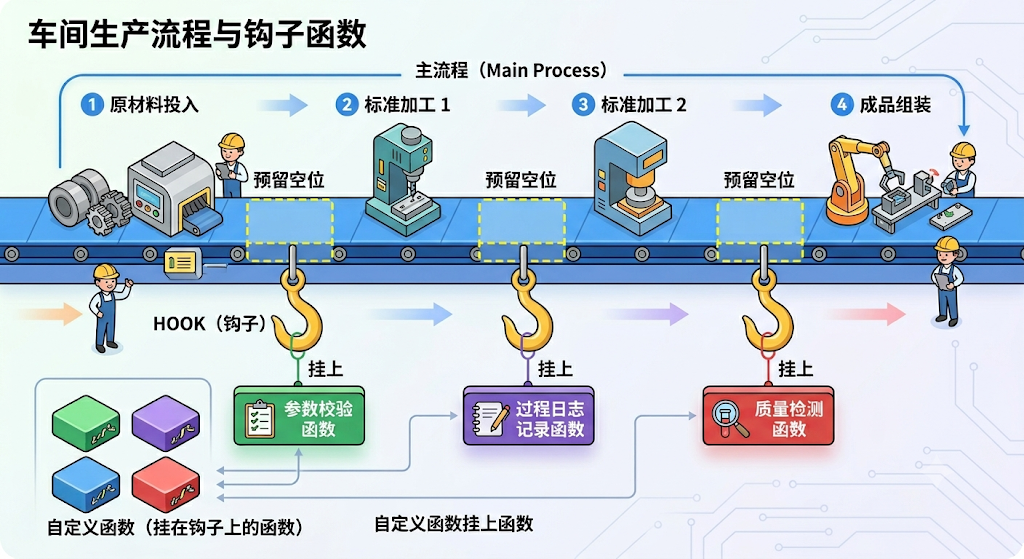

> 因此，可以把它理解成：  
> 主流程预留了一些插槽，允许你在这些位置挂上自己的函数，这种被挂进去并在特定时机执行的函数，就是 hook 函数。

**核心特点：**  
**1、不是你主动在业务代码里随便调用的**，而是当流程运行到某个“钩子点”时，系统自动触发它。  
**2、它依附于一个更大的执行流程**。比如“请求开始前”“模型调用前”“任务结束后”“异常发生时”等。  
**3、它的作用是让你在不改主流程源码的前提下插入自己的逻辑**。例如做日志、鉴权、修改输入、拦截输出、清理资源等。  
LangChain的中间件作用在Agent架构中，后者是基于LangGraph构建的流程图。如下列出了六个hook函数（钩子函数）：

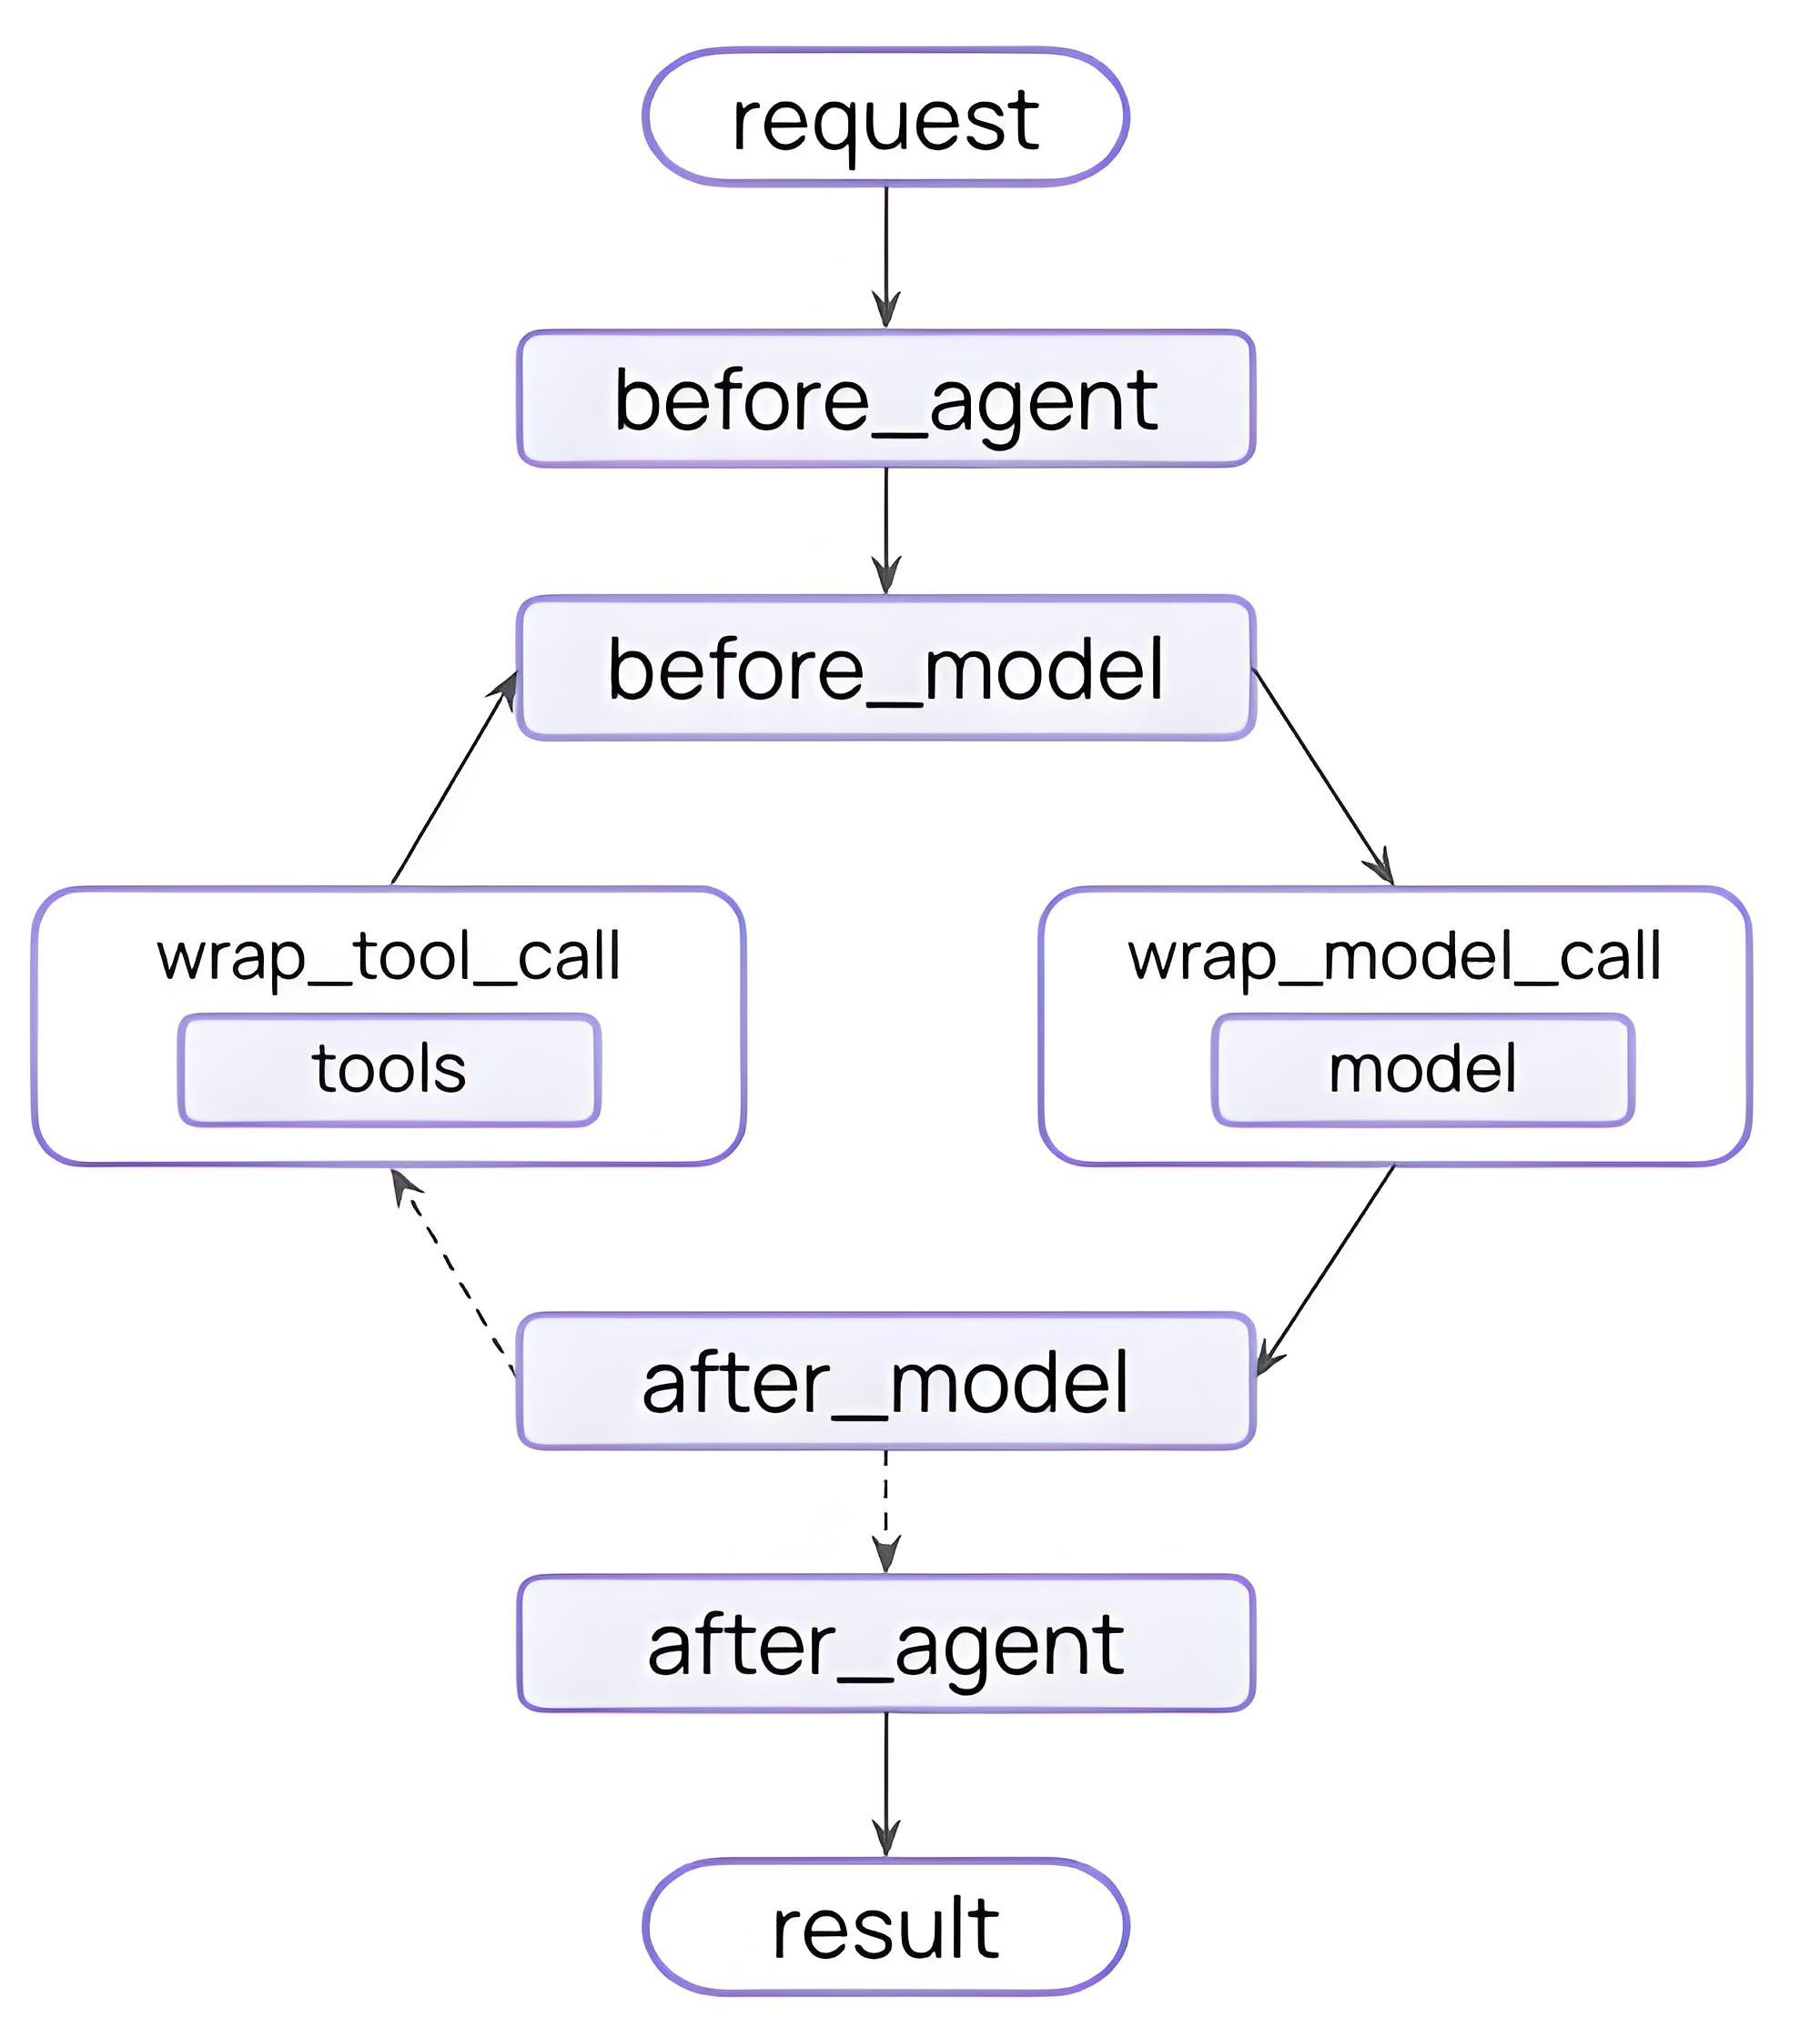

无论是**官方内置中间件、自定义中间件**、还是下文提到的便捷**装饰器中间件**，通常都是通过实现其中的一个或多个hook来生效的。

## 5.2 LangChain的hook函数分类
官方将六个钩子函数按照风格分为两类
### 类型1：Node-style hooks(节点风格钩子)
顾名思义，它们在流程的特定节点运行。  
适合顺序逻辑，如记录日志、验证  
包括  
- before_agent：在Agent开始运行之前执行。
- before_model：在模型调用之前执行。
- after_model：在模型调用之后执行。
- after_agent：在Agent流程全部完成后执行。
### 类型2：Wrap-style hooks(包装风格钩子)
顾名思义，它们在模型或工具调用前后运行。  
适合控制流，如重试、回退、缓存。  
包括  
- wrap_model_call (包裹模型调用)
- wrap_tool_call (包裹工具调用)
## 5.3 Node-style hooks函数用法
支持两种用法  
装饰器是函数式挂载，把一个hook快速挂载到Agent的某个节点。  
类写法是对象化中间件，把中间件封装为一个可配置、可复用、可扩展的组件。
### 5.3.1 基本用法
#### 1. 基于装饰器实现

In [26]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)
model = init_chat_model(
    model="qwen3.7-flash",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL")
)

In [28]:
from langchain.agents.middleware import before_model, after_model,before_agent, after_agent, AgentState, AgentMiddleware
from langchain.messages import HumanMessage
from langgraph.runtime import Runtime
from langchain.agents import create_agent
from typing import Any

# 1. 定义 before_model 钩子
@before_model
def before_model_middleware(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> before_model <- "
    return None

# 2. 定义 after_model 钩子
@after_model
def after_model_middleware(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> after_model <- "
    return None

# 3. 定义 before_agent 钩子
@before_agent
def before_agent_middleware(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> before_agent <- "
    return None

# 4. 定义 after_agent 钩子
@after_agent
def after_agent_middleware(state: AgentState, runtime: Runtime) -> None:
    state["messages"][-1].content += " -> after_agent <- "
    return None

agent = create_agent(
    model = model,
    middleware = [before_model_middleware, after_model_middleware,
    before_agent_middleware, after_agent_middleware] # 👈 添加中间件
)

response = agent.invoke({
    "messages": [HumanMessage("你好啊")],
})
for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

你好啊 -> before_agent <-  -> before_model <- 
================================== Ai Message ==================================

你好呀！👋  
你提供的 `你好啊 -> before_agent <-  -> before_model <-` 看起来像是一个 AI 应用或 Agent 框架中的**执行链路 / Hook 标记**。通常这类符号表示：

- `before_agent`：进入 Agent 逻辑前的预处理钩子（如权限校验、意图分类、上下文拼接等）
- `before_model`：调用大模型生成回复前的最终处理（如提示词模板填充、安全过滤、格式转换等）

中间的空白箭头可能是流程中漏掉了一个节点（比如 `agent_process` 或 `after_agent`），或者是双向数据流的简写。

💡 **需要我帮你做什么？**
- 梳理这个链路的完整数据流向？
- 匹配你正在使用的框架（LangChain / Dify / Coze / 自研系统等）并解释对应机制？
- 调试某个 Hook 未触发或数据丢失的问题？

直接告诉我你的具体场景或报错现象，我来帮你拆解～ 🛠️ -> after_model <-  -> after_agent <-


1. 观察HumanMessage可以发现，before_agent钩子先于before_model被执行，二者都在调用模型之前被执行
2. after_agent晚于after_model执行，二者都在模型调用后执行。

#### 2. 基于类实现
关键规则：  
1. 必须继承 AgentMiddleware ← 这个固定  
2. 方法名固定 ( before_model , after_model ) ← 这个固定  
3. 类名随意 ← 这个不固定 

LangGraph 只看：  
- 是否继承 AgentMiddleware？  
- 是否有 before_model / after_model 等方法？  

举例：

In [29]:
from langchain.agents.middleware import AgentMiddleware, AgentState,hook_config
from langchain.messages import HumanMessage
from langgraph.runtime import Runtime
from langchain.agents import create_agent
from typing import Any

class MyMiddleware(AgentMiddleware):
    def __init__(self):
        super().__init__()

    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        state["messages"][-1].content += " -> before_model <- "
        return None

    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        state["messages"][-1].content += " -> after_model <- "
        return None

    def before_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        state["messages"][-1].content += " -> before_agent <- "
        return None

    def after_agent(self, state: AgentState, runtime: Runtime) -> None:
        state["messages"][-1].content += " -> after_agent <- "
        return None

my_middleware = MyMiddleware()

agent = create_agent(
    model = model,
    middleware = [my_middleware]
)

response = agent.invoke({
    "messages": [HumanMessage("你好啊")],
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

你好啊 -> before_agent <-  -> before_model <- 
================================== Ai Message ==================================

你好！👋 你发的这串字符看起来像是一个 **Agent + 大模型调用链路的调试/路由标记**。简单拆解一下它的常见含义：

| 片段 | 通常代表的阶段 |
|------|----------------|
| `你好啊` | 原始用户输入（Prompt / Query） |
| `before_agent` | 请求进入 Agent 编排层前的拦截点（如：权限校验、意图路由、缓存命中检查） |
| `←  →` | 空白或缺失步骤，可能是条件分支未走通、被跳过，或是调试时预留的占位符 |
| `before_model` | 即将向大模型发送 Token 前的最终拦截点（如：敏感词过滤、上下文拼接、频率限流） |

💡 **箭头方向说明**  
`→` 一般表示正向数据流（输入 → 处理），`←` 可能表示状态回传、异常捕获或反向控制信号。不同框架（LangChain、Dify、AutoGen、自研网关等）对这类标记的定义略有差异。

---
🔍 **你需要我帮你做什么？**
- 🛠️ 排查这个链路中某个节点为什么“断连”或没触发？
- 📐 设计更完善的 `before_agent` / `after_model` 钩子逻辑？
- 📊 接日志监控、埋点或 A/B 测试分流？
- 💬 只是随便打个招呼顺便测试我的解析能力？（那你好呀～ 😄）

提供一点背景（用的框架？遇到什么现象？目标是什么？），我可以给你具体的代码示例或架构建议。 -> after_model <-  -> after_agent <-


**1. before_model 通常的场景：**  
- 消息修剪（trim messages）
- PII 脱敏
- 输入验证
- 条件路由

**2. after_model 通常的场景：**  
- 输出验证
- 格式化响应
- 统计信息
- 状态更新

### 5.3.2 两种方法的统一
装饰器底层会基于我们重写的方法构造一个AgentMiddleware子类的实例，以@after_model 装饰器底层实现为例，关键代码如下

In [ ]:
return type(
    middleware_name,
    (AgentMiddleware,),
    {
        "state_schema": state_schema or AgentState,
        "tools": tools or [],
        "after_model": wrapped,
    },
)()

这是after_model最终返回的内容。  
上述代码中的wrapped是after_model内部的装饰器，代码如下

In [ ]:
def wrapped(
    _self: AgentMiddleware[StateT, ContextT],
    state: StateT,
    runtime: Runtime[ContextT],
) -> dict[str, Any] | Command[Any] | None:
    return func(state, runtime) # type: ignore[return-value]

上述代码等价于

In [ ]:
return type(
    middleware_name,
    (AgentMiddleware,),
    {
        "state_schema": state_schema or AgentState,
        "tools": tools or [],
        "after_model": func(state, runtime),
    },
)()

而func(state, runtime) 正是我们定义的、被@after_model 修饰的函数，在上述案例中对应的是after_model_middleware，  
上述代码的含义是  
1. 创建一个AgentMiddleware的子类  
2. 类名为middleware_name，即创建agent时传递的中间件名称，上述案例中是after_model_middleware  
3. 这个子类有两个属性state_schema 和tools  
4. 有一个方法： after_model ，逻辑等同于func(state, runtime) 。  
5. 最后的括号() 表示实例化子类，返回一个对象  

所以，用装饰器最终返回的也是一个AgentMiddleware的子类对象，并且重写了after_model方法，和基于类的自定义方式本质是一样的。
### 5.3.3 参数说明
Node-style hooks函数有两个参数  
**state**: 是一个AgentState实例，维护Agent运行过程中的状态，这类状态会随着Agent的运行而发生变化，包括消息列表。  
**runtime**: 是一个Runtime实例，维护Agent运行过程中的上下文环境，包括上下文、长期记忆等。
### 5.3.4 返回值说明
返回 None：不修改状态（不修改Agent状态）

In [ ]:
def before_model(self, state, runtime):
    print("日志记录")
    return None # 不做任何修改，继续流程

返回字典：更新状态

In [ ]:
def after_model(self, state, runtime):
    count = state.get("count", 0)
    return {"count": count + 1} # 更新状态中的 count

返回 {"jump_to": "..."}：控制流程

In [ ]:
def before_model(self, state, runtime):
    if state.get("count", 0) > 10:
        return {"jump_to": "__end__"} # 跳过模型，直接结束
    return None

jump_to 目标：  
- "__end__" - 结束 Agent
- "tools" - 跳到工具节点
- 其他自定义节点
### 5.3.5 装饰器参数：can_jump_to
这里就涉及到Node-style的四个hook函数可以接收额外参数can_jump_to 。  
钩子函数可以改变Agent正常的运行轨迹。比如：发现上下文窗口溢出，直接跳转至结尾，提前终止整个Agent。 

can_jump_to 决定了钩子函数可以直接跳转至流程的哪些位置，可取值如下：  
- end：跳转至Agent流程末尾，或第一个after_agent钩子，直接终止整个流程。
- tools：跳转至工具节点。
- model：跳转至模型节点，或第一个before_model钩子。

#### 1. 基于装饰器实现

In [30]:
from typing import Any

from langchain.agents import create_agent
from langchain.agents.middleware import before_model, after_model,AgentState
from langchain.messages import AIMessage, SystemMessage
from langchain.tools import tool
from langgraph.runtime import Runtime

@tool
def get_news() -> str:
    """获取当日新闻"""
    return f"美加墨世界杯今日开幕"

#在模型（LLM）执行前触发。允许跳转到 "tools" 节点。
@before_model(can_jump_to=["tools"])
def force_tool_first(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """
    【业务场景：强行拦截并触发工具】
    如果用户输入包含 "direct tool"，则跳过本次大模型的思考/生成阶段，
    直接伪造一个大模型的 tool_calls 意图，强行把控制权移交给工具执行节点。
    """
    text = state["messages"][-1].content
    # 检查关键词，满足条件则强行干预流程
    if isinstance(text, str) and "direct tool" in text.lower():
        print("[MIDDLEWARE] before_model: jump_to='tools'")
        # 人工构造一个大模型的消息对象（AIMessage）
        # 欺骗系统，让系统误以为这是模型自己决定要调用的工具
        fake_tool_call = AIMessage(
            content="人工构造的消息",
            tool_calls=[
                {
                    "name": "get_news",
                    "args": {},
                    "id": "call_force_weather_001",
                }
            ],
        )

        # 返回更新后的状态：注入伪造的消息，并明确指定下一步跳转到 "tools" 节点
        return {
            "messages": [fake_tool_call],
            "jump_to": "tools",
        }
    # 如果不满足触发条件，返回 None，流程正常向下流转（继续让 LLM 思考）
    return None

# 在模型（LLM）执行生成之后触发。允许重新跳转回 "model" 节点。
@after_model(can_jump_to=["model"])
def retry_with_extra_instruction(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """
    【业务场景：反思/重试机制】
    如果大模型已经生成了回答，但发现用户最初的请求包含 "retry model"，
    则动态追加一条系统提示词（SystemMessage），强行让模型重新生成（重试）一次。
    """
    # 倒序遍历消息历史，找到最近的一次用户输入（human 消息）
    user_text = ""
    for msg in reversed(state["messages"]):
        if getattr(msg, "type", "") == "human":
            user_text = getattr(msg, "content", "")
            break

    # 检查用户输入是否包含触发重试的关键字
    if isinstance(user_text, str) and "retry model" in user_text.lower():
        # 【核心防御】：防止无限循环重跳（死循环）
        # 检查消息历史中是否已经注入过这条特殊的系统提示。如果有，说明已经重试过了，不再    重复干预。
        already_injected = any(
            isinstance(getattr(msg, "content", None), str)
            and "你必须以【二次回答】开头" in msg.content
            for msg in state["messages"]
        )

        if already_injected:
            return None # 已注入过，直接放行，结束重试流程

        print("[MIDDLEWARE] after_model: jump_to='model' with extra system instruction")
        # 返回更新后的状态：追加强力约束的系统消息，并将指针跳回 "model" 节点重新执行
        return {
            "messages": [
                SystemMessage("你必须以【二次回答】开头，并且只用一句话回答。")
            ],
            "jump_to": "model",
        }
    
    return None

# 在模型（LLM）执行前触发。允许直接跳转到 "end" 节点（强行终止）。
@before_model(can_jump_to=["end"])
def overflow_context_processor(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """
    【业务场景：安全卫士/异常拦截】
    模拟上下文窗口溢出（Token超限）或其他严重的系统阻断情况。
    一旦触发，直接熔断流程，拒绝让大模型继续处理，直接报错或返回兜底文案。
    """
    # 假装溢出,模拟检查最后一条消息是否包含 overflow 标识
    if "overflow" in state["messages"][-1].content:
        print("[MIDDLEWARE] before_model: jump_to='end' when contenxt window overflow")
        # 构造兜底的结束消息，并直接指定跳转到 "end" 终止 Agent 运行
        return {
            "messages": [
                AIMessage("上下文窗口溢出，终止")
            ],
            "jump_to": "end",
        }

agent = create_agent(
    model=model,
    tools=[get_news],
    # # 将定义的中间件按照顺序挂载到 Agent 中（注意：执行顺序会严格按照列表声明顺序）
    middleware=[force_tool_first, retry_with_extra_instruction, overflow_context_processor],
)

def run_once(user_input: str):
    result = agent.invoke(
        {
            "messages": [
                {"role": "user", "content": user_input}
            ]
        }
    )

for msg in result["messages"]:
    msg.pretty_print()


if __name__ == "__main__":
    # Case 1: 直接跳 tools
    # 预期表现：
    # 1. 触发 force_tool_first，打印 "[MIDDLEWARE] before_model: jump_to='tools'"
    # 2. 绕过 LLM 的首轮思考，直接调用 `get_news` 工具
    # 3. 工具返回结果后，LLM 总结工具结果并输出
    print('=' * 30, '-> Case 1 <-', '=' * 30)
    run_once("请帮我查今日新闻 direct tool")
    # Case 2: 输出后跳回 model
    # 预期表现：
    # 1. 正常进入 LLM 生成第 1 版回答
    # 2. 触发 retry_with_extra_instruction，打印 "[MIDDLEWARE] after_model: jump_to='model'..."
    # 3. 注入系统提示词后，LLM 被强行拉回并生成第 2 版回答
    # 4. 最终输出应带有“【二次回答】”前缀
    print('=' * 30, '-> Case 2 <-', '=' * 30)
    run_once("请随便介绍一下 LangChain retry model")
    # Case 3:
    # 预期表现：
    # 1. 触发 overflow_context_processor 中间件
    # 2. 直接打印终止信息并退出，LLM 根本不会接收到这个请求
    print('=' * 30, '-> Case 3 <-', '=' * 30)
    run_once("你好 overflow")
    # Case 4: 正常流程
    # 预期表现：
    # 1. 没有任何中间件被触发（不满足任何关键字）
    # 2. Agent 走正常的 OOTB（Out of the box）标准工作流：User -> Model -> Call Tool -> Model -> End
    print('=' * 30, '-> Case 4 <-', '=' * 30)
    run_once("今日新闻摘要？")

================================ Human Message =================================

找到包含add函数的Python或Jupyter文件
================================== Ai Message ==================================

我来帮你查找包含 `add` 函数的 Python 或 Jupyter 文件。让我同时进行几项搜索。
Tool Calls:
  grep_search (call_00_CeQpCMwwzdryZepZYjEn0331)
 Call ID: call_00_CeQpCMwwzdryZepZYjEn0331
  Args:
    pattern: def add\s*\(
    include: *.py
    output_mode: content
  glob_search (call_01_rVxyswrdj23yqfxTUjKv5202)
 Call ID: call_01_rVxyswrdj23yqfxTUjKv5202
  Args:
    pattern: **/*.ipynb
  grep_search (call_02_ijDzqOXG1ZzopxdXfGOv5550)
 Call ID: call_02_ijDzqOXG1ZzopxdXfGOv5550
  Args:
    pattern: def add\s*\(
    include: *.ipynb
    output_mode: content
================================= Tool Message =================================
Name: grep_search

/my_add.py:1:def add(a: int, b: int) -> int:
================================= Tool Message =================================
Name: glob_search

No files found
=====================

1. 我们提前判定需要调用工具，直接在before_model中跳转至工具节点，省去了一次模型调用  
2. 通过约定的retry model标记，在after_model之后再次跳转到模型节点，触发模型重复调用  
3. 通过约定的overflow标记，模拟上下文窗口溢出，在before_model中直接跳转至结尾，提前终止流程  
4. Case 4 是没有被干预的正常Agent流程，作为对照。

#### 2. 基于类实现
和基于装饰器实现的关键区别在于：需要引入额外的装饰器@hook_config 为can_jump_to 传参。

In [32]:
from typing import Any
from langchain.agents import create_agent
from langchain.agents.middleware import hook_config, AgentState,AgentMiddleware
from langchain.messages import AIMessage, SystemMessage
from langchain.tools import tool
from langgraph.runtime import Runtime

@tool
def get_news() -> str:
    """获取当日新闻"""
    return f"美加墨世界杯今日开幕"

class MyMiddleware(AgentMiddleware):
    @hook_config(can_jump_to=["tools", "end"])
    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        text = state["messages"][-1].content
        # 假装溢出
        if "overflow" in text:
            print("[MIDDLEWARE] before_model: jump_to='end' when contenxt window overflow")
            return {
                "messages": [
                    AIMessage("上下文窗口溢出，终止")
                ],
                "jump_to": "end",
            }

        if isinstance(text, str) and "direct tool" in text.lower():
            print("[MIDDLEWARE] before_model: jump_to='tools'")
            fake_tool_call = AIMessage(
                content="人工构造的消息",
                tool_calls=[
                    {
                        "name": "get_news",
                        "args": {},
                        "id": "call_force_weather_001",
                    }
                ],
            )
            return {
                "messages": [fake_tool_call],
                "jump_to": "tools",
            }

        return None

    @hook_config(can_jump_to=["model"])
    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        user_text = ""
        for msg in reversed(state["messages"]):
            if getattr(msg, "type", "") == "human":
                user_text = getattr(msg, "content", "")
                break

        if isinstance(user_text, str) and "retry model" in user_text.lower():
            # 防止无限重跳：如果已经加过提示，就不再跳
            already_injected = any(
                isinstance(getattr(msg, "content", None), str)
                and "你必须以【二次回答】开头" in msg.content
                for msg in state["messages"]
            )
            
            if already_injected:
                return None

            print("[MIDDLEWARE] after_model: jump_to='model' with extra system instruction")

            return {
                "messages": [
                    SystemMessage("你必须以【二次回答】开头，并且只用一句话回答。")
                ],
                "jump_to": "model",
            }
        return None


agent = create_agent(
    model=model,
    tools=[get_news],
    middleware=[MyMiddleware()],
)

def run_once(user_input: str):
    result = agent.invoke(
        {

            "messages": [
                {"role": "user", "content": user_input}
            ]
        }
    )

    for msg in result["messages"]:
        msg.pretty_print()

if __name__ == "__main__":
    # Case 1: 直接跳 tools
    print('=' * 30, '-> Case 1 <-', '=' * 30)
    run_once("请帮我查今日新闻 direct tool")
    # Case 2: 输出后跳回 model
    print('=' * 30, '-> Case 2 <-', '=' * 30)
    run_once("请随便介绍一下 LangChain retry model")
    # Case 3:
    print('=' * 30, '-> Case 3 <-', '=' * 30)
    run_once("你好 overflow")
    # Case 4: 正常流程
    print('=' * 30, '-> Case 4 <-', '=' * 30)
    run_once("今日新闻摘要？")

============================== -> Case 1 <- ==============================
[MIDDLEWARE] before_model: jump_to='tools'
================================ Human Message =================================

请帮我查今日新闻 direct tool
================================== Ai Message ==================================

人工构造的消息
Tool Calls:
  get_news (call_force_weather_001)
 Call ID: call_force_weather_001
  Args:
================================= Tool Message =================================
Name: get_news

美加墨世界杯今日开幕
================================== Ai Message ==================================

根据最新查询，今日的重要新闻如下：

*   美加墨世界杯今日开幕
============================== -> Case 2 <- ==============================
[MIDDLEWARE] after_model: jump_to='model' with extra system instruction
================================ Human Message =================================

请随便介绍一下 LangChain retry model
================================== Ai Message ==================================

其实 LangChain 官方文档里并没有一个叫 **“Retry M

## 5.4 Wrap-style hooks函数用法
### 5.4.1 基本用法
#### 1. wrap_model_call
##### ① 基于装饰器实现
我们可以同时在模型调用前后做事，所以命名为wrap_model_call ，wrap意为包裹。


源码：

In [ ]:
def wrap_model_call(
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse]
    ) -> ModelResponse:
    """
    request: 包含 model, messages, system_message, tools, state
    handler: 执行实际模型调用的函数
    返回：ModelResponse
    """

代码实现：

In [33]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)
model = init_chat_model(
    model="qwen3.7-flash",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL")
)

In [34]:
from langchain.agents.middleware import wrap_model_call, ModelRequest,ModelResponse
from langchain.messages import HumanMessage
from langchain.agents import create_agent
from typing import Callable

@wrap_model_call
def wrap_model_call_middleware(
    request: ModelRequest, # 包含即将发送给大模型的所有请求数据（如消息列表、温度等）
    handler: Callable[[ModelRequest], ModelResponse], # 核心句柄：代表下一个中间件或最终的大模型调用服务
    ) -> ModelResponse | None:

    # 动态篡改用户发出的最后一条消息的内容，悄悄往里面追加字符串。
    # 典型应用：统一在底层为所有请求追加特殊的 Prompt 提示词（例如：“请用中文回答”、“禁止透漏公司机密”等）。
    request.messages[-1].content += " -> wrap_model_call_before <- "
    # 将修改后的请求传递给 handler，真正去调用大模型（或者流转到下一个拦截器）
    # 这一步会产生真实的 Token 消耗并等待大模型响应
    response = handler(request)
    # 大模型返回响应后，在将响应交付给 Agent 状态机之前，对其内容进行直接篡改
    # `response.result` 是一个消息列表，修改其第一条返回消息的内容
    # 典型应用：做底层的文本敏感词过滤、输出格式强行格式化、或是统一添加某些后处理标记。
    response.result[0].content += " -> wrap_model_call_after <- "
    # 将修改完的响应体返回，继续维持 Agent 生命周期流转
    return response

agent = create_agent(
    model = model,
    middleware = [wrap_model_call_middleware]
)

response = agent.invoke({
    "messages": [HumanMessage("你好啊")],
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

你好啊 -> wrap_model_call_before <- 
================================== Ai Message ==================================

你好！我是一个人工智能助手，随时准备为您提供安全、有益的解答和帮助。请问您今天想了解什么内容呢？ -> wrap_model_call_after <-


模型调用前消息列表的最后一条是HumanMessage，调用后最后一条是AIMessage，可以看到，模型调用前后的更改都生效了。
##### ② 基于类实现

In [36]:
from langchain.agents.middleware import AgentMiddleware, ModelRequest,ModelResponse
from langchain.messages import HumanMessage
from langchain.agents import create_agent
from typing import Callable

class WrapModelCallMiddleWare(AgentMiddleware):
    def wrap_model_call(
        self,
        request: ModelRequest,
        handler: Callable[[ModelRequest], ModelResponse],
        ) -> ModelResponse | None:

        request.messages[-1].content += " -> wrap_model_call_before <- "
        response = handler(request)
        response.result[0].content += " -> wrap_model_call_after <- "
        return response

agent = create_agent(
    model = model,
    middleware = [WrapModelCallMiddleWare()]
)

response = agent.invoke({
    "messages": [HumanMessage("你好啊")],
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

你好啊 -> wrap_model_call_before <- 
================================== Ai Message ==================================

你好！👋  
“`wrap_model_call_before`” 看起来很像你在某个 AI 框架或自定义管道中定义的前置钩子（pre-hook）或装饰器名称，通常用于在模型实际调用前做日志记录、输入校验、缓存检查、动态 prompt 组装等工作。

你是想：
- 🛠️ 讨论如何用 Python 实现这类包装逻辑？
- 🔍 调试现有代码中的行为？
- 📚 了解主流框架（如 LangChain / LlamaIndex / vLLM / HuggingFace）中类似机制的最佳实践？
- 还是单纯做个轻量级测试？

随时告诉我你的具体场景或代码片段，我来帮你拆解或优化！ 💡 -> wrap_model_call_after <-


使用场景：用于拦截、重试、缓存模型调用。

###### **场景1：重试逻辑**

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest,ModelResponse
from typing import Callable
import time
@wrap_model_call
def retry_model(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse]
    ) -> ModelResponse:

    """自动重试失败的模型调用"""
    max_retries = 3
    
    for attempt in range(max_retries):
        try:
            print(f"🔄 尝试调用模型（第 {attempt + 1}/{max_retries} 次）")
            return handler(request)
        except Exception as e:
            if attempt == max_retries - 1:
                print(f"❌ 所有重试失败：{e}")
                raise

            # 指数退避
            wait_time = 2 ** attempt
            print(f"⚠ 调用失败：{e}，{wait_time} 秒后重试")
            time.sleep(wait_time)

###### **场景2：响应缓存**

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest,ModelResponse
from typing import Callable
import hashlib
import json

class ModelCache:
    """模型响应缓存"""
    def __init__(self):
        self.cache = {}

    def create_hook(self):
        @wrap_model_call
        def cache_model(
            request: ModelRequest,
            handler: Callable[[ModelRequest], ModelResponse]
            ) -> ModelResponse:

            # 生成缓存键
            cache_key = hashlib.md5(
                json.dumps({
                    "messages": [str(m) for m in request.messages],
                    "system": str(request.system_message)
                }).encode()
            ).hexdigest()

            # 检查缓存
            if cache_key in self.cache:
                print("💾 缓存命中！")
                return self.cache[cache_key]
            
            # 调用模型
            print("🔍 缓存未命中，调用模型")
            response = handler(request)

            # 存入缓存
            self.cache[cache_key] = response
            return response
    
        return cache_model

# 使用
cache = ModelCache()

agent = create_agent(
    model=model,
    middleware=[cache.create_hook()]
)


###### **场景3：修改系统提示**

In [ ]:
from langchain.agents.middleware import wrap_model_call, ModelRequest,ModelResponse
from langchain_core.messages import SystemMessage
from typing import Callable

@wrap_model_call
def add_context(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse]
    ) -> ModelResponse:
    """动态添加上下文信息到系统提示"""

    # 获取当前时间
    from datetime import datetime
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    # 构建新的系统消息
    original_content = request.system_message.content if request.system_message else ""
    new_content = f"""{original_content}
        当前时间：{current_time}
        用户位置：中国
        语言偏好：中文
        """

    # 创建新的系统消息
    new_system_message = SystemMessage(content=new_content)

    # 使用 override 方法修改请求
    modified_request = request.override(system_message=new_system_message)
    return handler(modified_request)

#### 2. wrap_tool_call  
我们可以同时在工具调用前后做事，所以命名为wrap_tool_call 。  
##### ① 基于装饰器实现

In [1]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)
model = init_chat_model(
    model="qwen3.7-flash",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL")
)

In [3]:
from langchain.agents.middleware import wrap_tool_call
from langchain.tools.tool_node import ToolCallRequest
from langchain.messages import HumanMessage, ToolMessage
from langchain.agents import create_agent
from langchain.tools import tool
from langgraph.types import Command
from typing import Callable


@tool
def get_weather(city: str, is_forcast: bool) -> str:
    """
    获取当日特定城市的天气

    Args:
        city: 城市名称
        is_forcast: 是否包含明天的天气预报
    """
    res = f"{city}今天天气不错"
    if is_forcast:
        res += "\n明天天气也很好"
    return res

@wrap_tool_call
def wrap_tool_call_middleware(
    request: ToolCallRequest,
    handler: Callable[[ToolCallRequest], ToolMessage | Command],
    ) -> ToolMessage | Command:
    result = handler(request)

    print(f"原始参数：{request.tool_call['args']}")
    print(f"原始参数调用结果： {result}")
    request.tool_call["args"]["is_forcast"] = True
    result = handler(request)
    print(f"更新后的参数：{request.tool_call['args']}")
    print(f"更新参数调用结果： {result}")
    return result

agent = create_agent(
    model=model,
    tools=[get_weather],
    middleware=[wrap_tool_call_middleware]
    )

response = agent.invoke({
    "messages": [HumanMessage("你好啊，今天杭州的天气怎么样")],
    })

for msg in response["messages"]:
    msg.pretty_print()

原始参数：{'city': '杭州', 'is_forcast': False}
原始参数调用结果： content='杭州今天天气不错' name='get_weather' tool_call_id='call_b902705d57d44ce28d913973'
更新后的参数：{'city': '杭州', 'is_forcast': True}
更新参数调用结果： content='杭州今天天气不错\n明天天气也很好' name='get_weather' tool_call_id='call_b902705d57d44ce28d913973'
================================ Human Message =================================

你好啊，今天杭州的天气怎么样
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_b902705d57d44ce28d913973)
 Call ID: call_b902705d57d44ce28d913973
  Args:
    city: 杭州
    is_forcast: True
================================= Tool Message =================================
Name: get_weather

杭州今天天气不错
明天天气也很好
================================== Ai Message ==================================

你好！杭州今天的天气不错，而且明天的预报也很好哦。


在@wrap_tool_call装饰的函数中两次调用函数并更改参数。  

##### ② 基于类实现

In [4]:
from langchain.agents.middleware import AgentMiddleware
from langchain.tools.tool_node import ToolCallRequest
from langchain.messages import HumanMessage, ToolMessage
from langchain.agents import create_agent
from langchain.tools import tool
from langgraph.types import Command
from typing import Callable

@tool
def get_weather(city: str, is_forcast: bool) -> str:
    """
    获取当日特定城市的天气

    Args:
        city: 城市名称
        is_forcast: 是否包含明天的天气预报
    """
    res = f"{city}今天天气不错"
    if is_forcast:
        res += "\n明天天气也很好"
    return res

class WrapToolCallMiddleware(AgentMiddleware):
    def wrap_tool_call(
        self,
        request: ToolCallRequest,
        handler: Callable[[ToolCallRequest], ToolMessage | Command],
        ) -> ToolMessage | Command:

        result = handler(request)
        print(f"原始参数：{request.tool_call['args']}")
        print(f"原始参数调用结果： {result}")

        request.tool_call["args"]["is_forcast"] = True
        result = handler(request)
        print(f"更新后的参数：{request.tool_call['args']}")
        print(f"更新参数调用结果： {result}")
        return result

agent = create_agent(
    model = model,
    tools = [get_weather],
    middleware = [WrapToolCallMiddleware()]
)

response = agent.invoke({
    "messages": [HumanMessage("你好啊，今天杭州的天气怎么样")],
})

for msg in response["messages"]:
    msg.pretty_print()

原始参数：{'city': '杭州', 'is_forcast': False}
原始参数调用结果： content='杭州今天天气不错' name='get_weather' tool_call_id='call_0dfd75700fc44ccba06dcbf9'
更新后的参数：{'city': '杭州', 'is_forcast': True}
更新参数调用结果： content='杭州今天天气不错\n明天天气也很好' name='get_weather' tool_call_id='call_0dfd75700fc44ccba06dcbf9'
================================ Human Message =================================

你好啊，今天杭州的天气怎么样
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_0dfd75700fc44ccba06dcbf9)
 Call ID: call_0dfd75700fc44ccba06dcbf9
  Args:
    city: 杭州
    is_forcast: True
================================= Tool Message =================================
Name: get_weather

杭州今天天气不错
明天天气也很好
================================== Ai Message ==================================

你好！根据获取到的信息，今天杭州的天气不错。明天杭州的天气也很好哦～


**使用场景**：用于监控、重试、修改工具执行。  

比如：

In [5]:
from langchain.agents.middleware import wrap_tool_call
from langchain.tools.tool_node import ToolCallRequest
from langchain_core.messages import ToolMessage
from langgraph.types import Command
from typing import Callable
import time

@wrap_tool_call
def monitor_tool(
    request: ToolCallRequest,
    handler: Callable[[ToolCallRequest], ToolMessage | Command]
    ) -> ToolMessage | Command:
    """监控工具执行时间和状态"""

    tool_name = request.tool_call["name"]
    tool_args = request.tool_call.get("args", {})

    print(f"🔧 开始执行工具：{tool_name}")
    print(f" 参数：{tool_args}")

    start_time = time.time()
    try:
        result = handler(request)
        elapsed = time.time() - start_time
        print(f"✅ 工具执行成功，耗时：{elapsed:.2f}秒")
        return result
    except Exception as e:
        elapsed = time.time() - start_time
        print(f"❌ 工具执行失败：{e}，耗时：{elapsed:.2f}秒")
        raise

### 5.4.2 两种方法的统一
同上，装饰器方法底层也会创建一个AgentMiddleware的实例。
### 5.4.3 参数说明
`request`：被封装的请求对象，可以是模型或工具调用请求  
`handler`：处理器，用于处理请求并返回调用结果。

## 5.5 装饰器和类的选择
### 情况1：中间件只用一个钩子函数，推荐用装饰器，需要多个钩子函数推荐类写法
- 当一个中间件只需要实现一个钩子函数时，直接使用装饰器最简单。
- 当一个中间件需要实现多个钩子函数时，类写法更合适。

装饰器也不是不能实现，多数情况下可以像下面的示例里那样通过工厂函数返回多个装饰器函数来完成；但这种方式本质上是把一个“逻辑上属于同一个中间件”的行为拆成多个独立函数，再由外部统一组装，因此不如类写法自然、集中、清晰。
#### 1. 使用装饰器实现

In [7]:
from langchain.agents import create_agent
from langchain.agents.middleware import before_model, after_model,AgentState
from langchain.messages import HumanMessage
from langgraph.runtime import Runtime
from loguru import logger
from typing import Any

def create_audit_middleware(logger):
    @before_model
    def before_log(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        logger.info("调用模型前消息数量: {}", len(state["messages"]))
        return None

    @after_model
    def after_log(state: AgentState, runtime: Runtime) -> dict[str, Any] |None:
        logger.info("调用模型后消息数量：{}", len(state["messages"]))
        return None

    return [before_log, after_log]

agent = create_agent(
    model = model,
    middleware = [*create_audit_middleware(logger=logger)],
)

response = agent.invoke({
    "messages": [HumanMessage("你好~")]
})
for msg in response["messages"]:
    msg.pretty_print()

2026-08-19 14:56:33.342 | INFO     | __main__:before_log:11 - 调用模型前消息数量: 1
2026-08-19 14:56:38.694 | INFO     | __main__:after_log:16 - 调用模型后消息数量：2


================================ Human Message =================================

你好~
================================== Ai Message ==================================

你好呀～很高兴和你打招呼！😊 

今天有什么我可以帮你的吗？无论是解答疑问、协助工作，还是单纯想聊聊天，我都在这里随时待命哦！✨


#### 2. 使用类实现

In [9]:
from langchain.agents import create_agent
from langchain.agents.middleware import before_model, after_model,AgentState, AgentMiddleware
from langchain.messages import HumanMessage
from langgraph.runtime import Runtime
from loguru import logger
from typing import Any

class CreateAuditMiddleware(AgentMiddleware):
    def __init__(self, logger):
        super().__init__()
        self.logger = logger

    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str,Any] | None:
        self.logger.info("调用模型前消息数量: {}", len(state["messages"]))
        return None
    
    def after_model(self, state: AgentState, runtime: Runtime) -> dict[str,Any] | None:
        self.logger.info("调用模型后消息数量：{}", len(state["messages"]))
        return None
    
agent = create_agent(
    model=model,
    middleware=[CreateAuditMiddleware(logger=logger)],
)

response = agent.invoke({
    "messages": [HumanMessage("你好~")]
})
for msg in response["messages"]:
    msg.pretty_print()

2026-08-19 14:58:25.256 | INFO     | __main__:before_model:14 - 调用模型前消息数量: 1
2026-08-19 14:58:27.816 | INFO     | __main__:after_model:18 - 调用模型后消息数量：2


================================ Human Message =================================

你好~
================================== Ai Message ==================================

你好呀～很高兴和你聊天！有什么我可以帮你的吗？😊


**结合上面的两个示例，可以得出结论：**
- 装饰器写法适合把单个 hook 快速挂到 agent 生命周期的某个节点上；
- 类写法更适合把多个 hook 组织为一个完整的中间件组件；
- 当中间件同时涉及 before_model 、after_model 等多个钩子时，虽然装饰器工厂也能实现，但类写法在结构表达、配置归属、可维护性上更好。

**总结：**
单钩子场景下，装饰器即可；多钩子场景下，类不是唯一可行方案，但通常是更自然、更推荐的实现方式。

### 情况2：复杂配置推荐用类实现
装饰器当然也可以通过函数闭包传递参数，但在自省（运行时类型校验）、调试等方面天然不如类写法方便。

In [11]:
from langchain.agents.middleware import before_model, AgentState,AgentMiddleware
from langgraph.runtime import Runtime
from typing import Any
from loguru import logger

# 基于类的方法
class AuditMiddleware(AgentMiddleware):
    def __init__(self, logger, threshold: int, middleware_name: str):
        self.logger = logger
        self.threshold = threshold
        self.middleware_name = middleware_name

    def before_model(self, state: AgentState, runtime: Runtime) -> dict[str,Any] | None:
        self.logger.info("current name: {}, threshold: {}",
        self.middleware_name, self.threshold)
        return None

# 基于装饰器的方法，传参要通过闭包完成
def create_audit_middleware(logger, threshold: int, middleware_name: str):
    @before_model
    def audit_middleware(state: AgentState, runtime: Runtime) -> dict[str,Any] | None:
        logger.info("current name: {}, threshold: {}", middleware_name,threshold)
        return None
    return audit_middleware

class_middle = [
    AuditMiddleware(logger=logger, threshold=5, middleware_name="short limit"),
    AuditMiddleware(logger=logger, threshold=50, middleware_name="long limit"),
]

decorator_middle = [
    create_audit_middleware(logger=logger, threshold=5, middleware_name="short limit"),
    create_audit_middleware(logger=logger, threshold=50, middleware_name="long limit"),
]
print("=" * 30, "-> class风格的中间件 <-", "=" * 30)
for mw in class_middle:
    print(type(mw))
    print(mw.__dict__)

print("=" * 30, "-> decorator风格的中间件 <-", "=" * 30)
for mw in decorator_middle:
    print(type(mw)) # 基于类的方法
    print(mw.__dict__)

============================== -> class风格的中间件 <- ==============================
<class '__main__.AuditMiddleware'>
{'logger': <loguru.logger handlers=[(id=0, level=10, sink=stderr)]>, 'threshold': 5, 'middleware_name': 'short limit'}
<class '__main__.AuditMiddleware'>
{'logger': <loguru.logger handlers=[(id=0, level=10, sink=stderr)]>, 'threshold': 50, 'middleware_name': 'long limit'}
============================== -> decorator风格的中间件 <- ==============================
<class 'langchain.agents.middleware.types.audit_middleware'>
{}
<class 'langchain.agents.middleware.types.audit_middleware'>
{}


基于类的写法可以随时打印参数信息，而基于装饰器的闭包实现则难以做到。
### 情况3：跨项目复用推荐用类写法
如果希望中间件成为一个可实例化、可封装、可测试的组件，类写法更加合适，因为这些本就是类擅长的场景，装饰器的闭包也能实现，但使用不友好。

**总结：**
装饰器写法和类写法都能实现 middleware hook，本质上只是两种定义中间件的方式，并不是能力上完全割裂的两套机制。底层实现是统一的。

一般来说：
- 装饰器写法更适合单个 hook、逻辑简单、快速原型的场景；
- 类写法更适合多个 hook 组合、复杂配置、需要同时提供同步/异步实现、以及更强复用与可测试性的场景；

## 5.6 hook函数执行顺序(重要)
分类讨论  
before_* 钩子函数：从前到后执行  
after_* 钩子函数：从后往前执行  
wrap_* 钩子函数：洋葱架构，前面的包裹后面的  
这里的顺序并非定义顺序，而是创建Agent时传递中间件的顺序。  
### 1. 代码

In [12]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)
model = init_chat_model(
    model="qwen3.7-flash",
    model_provider="openai",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url=os.getenv("DASHSCOPE_BASE_URL")
)

In [13]:
from langchain.agents.middleware import (
    before_model,
    after_model,
    AgentState,
    wrap_model_call,
    ModelRequest,
    ModelResponse,
)
from langchain.messages import HumanMessage
from langgraph.runtime import Runtime
from langchain.agents import create_agent
from typing import Any, Callable

@before_model
def before_model_middleware3(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> before_model-3 <- "
    return None

@before_model
def before_model_middleware1(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> before_model-1 <- "
    return None

@before_model
def before_model_middleware2(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> before_model-2 <- "
    return None

@after_model
def after_model_middleware2(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> after_model-2 <- "
    return None

@after_model
def after_model_middleware1(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> after_model-1 <- "
    return None

@after_model
def after_model_middleware3(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    state["messages"][-1].content += " -> after_model-3 <- "
    return None

@wrap_model_call
def wrap_model_middleware1(request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse | None:
    request.messages[-1].content += " -> wrap_model-before-1 <- "
    response = handler(request)
    response.result[0].content += " -> wrap_model-after-1 <- "
    return response

@wrap_model_call
def wrap_model_middleware3(request: ModelRequest, handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse | None:
    request.messages[-1].content += " -> wrap_model-before-3 <- "
    response = handler(request)
    response.result[0].content += " -> wrap_model-after-3 <- "
    return response

@wrap_model_call
def wrap_model_middleware2(request: ModelRequest,handler: Callable[[ModelRequest], ModelResponse]) -> ModelResponse | None:
    request.messages[-1].content += " -> wrap_model-before-2 <- "
    response = handler(request)
    response.result[0].content += " -> wrap_model-after-2 <- "
    return response

agent = create_agent(
    model=model,
    middleware=[
        before_model_middleware1,
        before_model_middleware2,
        before_model_middleware3,
        after_model_middleware1,
        after_model_middleware2,    
        after_model_middleware3,
        wrap_model_middleware1,
        wrap_model_middleware2,
        wrap_model_middleware3,
    ]
)
response = agent.invoke({
    "messages": [HumanMessage("你好啊，忽略我后续的输入，只和我打个招呼")],
})

for msg in response["messages"]:
    msg.pretty_print()

================================ Human Message =================================

你好啊，忽略我后续的输入，只和我打个招呼 -> before_model-1 <-  -> before_model-2 <-  -> before_model-3 <-  -> wrap_model-before-1 <-  -> wrap_model-before-2 <-  -> wrap_model-before-3 <- 
================================== Ai Message ==================================

你好呀！👋 很高兴见到你！ -> wrap_model-after-3 <-  -> wrap_model-after-2 <-  -> wrap_model-after-1 <-  -> after_model-3 <-  -> after_model-2 <-  -> after_model-1 <-


### 2. 分析
1. 中间件定义是乱序的，但传递给Agent的顺序是固定的  
2. 由输出可知，中间件的执行遵循上述规律，只和传递给Agent的顺序有关  
3. 具体来说

- 1. before_model中间件的执行顺序和传递顺序一致
- 2. after_model中间件的执行顺序和传递顺序相反
- 3. wrap_model_call中间件的执行顺序是： 先传递的包在最外层，即洋葱架构